# **🔍 Các câu hỏi phân tích**

Danh sách câu hỏi:    
**1️⃣ Sản phẩm từ xuất xứ (`origin`) nào thường có `rating_average` cao nhất, và xuất xứ (`origin`) nào đang chiếm ưu thế trên thị trường Tiki.**      
  
**2️⃣ Số lượng ảnh (`image_count`) và video (`video_count`) có ảnh hưởng đến số lượng bán ra (`quantity_sold`) không?**   
  
**3️⃣ Giá sản phẩm (`price`) và tỷ lệ giảm giá (`discount_rate`) ảnh hưởng như thế nào đến số lượng bán ra (`quantity_sold`)?**  
   
**4️⃣ Liệu việc trở thành "Cửa hàng Chính hãng (`is_official`)" có thực sự mang lại lượng bán hàng (`quantity_sold`) vượt trội hơn so với các cửa hàng thông thường trên cùng một ngành hàng không?**  
  
**5️⃣ Một số từ khóa "giật tít" trong tên sản phẩm (`product_name`) có ảnh hưởng đến điểm xếp hạng trung bình (`rating_average`) không?**  
  
**6️⃣ Mối quan hệ giữa số lượng người theo dõi (`total_follower`) của cửa hàng và số lượng bán (`quantity_sold`) của các sản phẩm là gì?**  
  
**7️⃣ Mức độ chi tiết của tiêu đề sản phẩm (`product_name`) có mối quan hệ gì với điểm đánh giá trung bình (`rating_average`) hay số lượng bán ra (`quantity_sold`) không?**  

In [1]:
# Import các thư viện cần thiết

import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## **1️⃣ Sản phẩm từ xuất xứ (origin) nào thường có `rating_average` cao nhất, và xuất xứ (origin) nào đang chiếm ưu thế trên thị trường Tiki.**

**Mục tiêu:** Xác định liệu các xuất xứ đang chiếm ưu thế về số lượng sản phẩm trên Tiki có đồng thời được người tiêu dùng đánh giá cao về chất lượng hay không.  
  
**Cách thức thực hiện:**

1. Tiền xử lý dữ liệu xuất xứ (origin):
Chuẩn hóa trường origin bằng cách tách các giá trị nhiều quốc gia, loại bỏ khoảng trắng và giá trị rỗng để đảm bảo mỗi sản phẩm chỉ gắn với một xuất xứ hợp lệ.

2. Gắn lại dữ liệu xuất xứ vào tập dữ liệu gốc:
Sau khi tách origin, liên kết lại với các biến liên quan như `rating_average` và `quantity_sold` để phục vụ phân tích.

3. Phân tích mức độ chiếm ưu thế của xuất xứ:
Đếm số lượng sản phẩm theo từng xuất xứ nhằm xác định các quốc gia có độ phủ thị trường cao nhất trên Tiki.

4. Phân tích chất lượng cảm nhận theo xuất xứ:
Tính giá trị `rating_average` trung bình của từng xuất xứ để xác định xuất xứ nào được người tiêu dùng đánh giá cao nhất.

5. Trực quan hóa và so sánh:
Sử dụng biểu đồ cột để so sánh giữa độ phổ biến và mức đánh giá trung bình, từ đó rút ra nhận định về mối quan hệ giữa quy mô thị trường và chất lượng đánh giá.

In [2]:
# Đọc dữ liệu
filepath = "../data/processed/data_before_reduction.csv"
df = pd.read_csv(filepath)

In [3]:
# Bước 1: Chuẩn hoá + split
origin_exploded = (
    df['origin']
    .str.replace('/', ',', regex=False)
    .str.replace(';', ',', regex=False)
    .str.split(',')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)

# Bước 2: Tạo cột mới cho origin đã clean và được tách
df_origin = df.loc[origin_exploded.index].copy()
df_origin['origin_clean'] = origin_exploded

df_origin.head(5)

,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,store_id,store_name,store_review_count,total_follower,is_official,cancel_by_seller_rate,cancel_by_seller_rate_status,return_rate,return_rate_status,origin_clean
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.359364,0.0,3.091042,...,18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal,Japan
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.359364,0.0,3.091042,...,18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal,Vietnam
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.496508,...,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal,Vietnam
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.258097,...,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal,Vietnam
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,2.772589,...,18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal,Japan


In [4]:
# Bước 3: Đếm tần suất các quốc gia (lấy 20 quốc gia cao nhất)
origin_count = (
    df_origin['origin_clean']
    .value_counts()
    .head(20)
)
origin_count.head(5)

origin_clean
Vietnam     10674
China        5245
Other        1180
Japan         676
Thailand      649
Name: count, dtype: int64

In [5]:
# Bước 4: Tính average rating giữa các quốc gia (lấy 20 quốc gia cao nhất)
origin_rating = (
    df_origin
    .groupby('origin_clean')['rating_average']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
origin_rating.head(5)

origin_clean
Ukraine        5.000
Finland        4.825
Switzerland    4.450
Brazil         4.300
Sri Lanka      4.000
Name: rating_average, dtype: float64

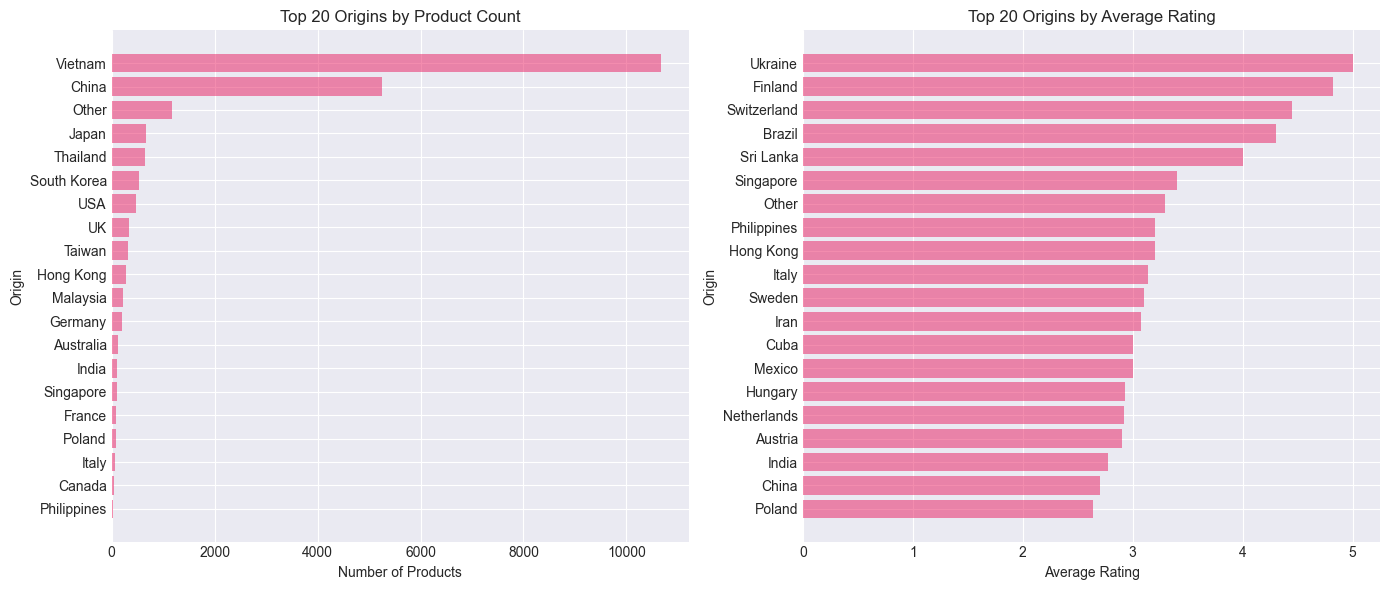

In [6]:
# Bước 5: Visualizing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ 1: Độ phổ biến
axes[0].barh(origin_count.index, origin_count.values, color = "#E91B5F", alpha = 0.5)
axes[0].set_title('Top 20 Origins by Product Count')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Origin')
axes[0].invert_yaxis()

# Biểu đồ 2: Rating trung bình
axes[1].barh(origin_rating.index, origin_rating.values, color = "#E91B5F", alpha = 0.5)
axes[1].set_title('Top 20 Origins by Average Rating')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Origin')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### **✍️ Nhận xét:**

**1. Biểu đồ bên trái: Top 20 Origins by Product Count (Số lượng sản phẩm)**
- Biểu đồ này phản ánh quy mô và sự thống trị của các nguồn hàng trên sàn.

- Sự thống trị tuyệt đối của Việt Nam: Việt Nam đứng đầu với hơn 10.000 sản phẩm, vượt xa tất cả các quốc gia khác. Điều này cho thấy sàn thương mại điện tử này tập trung mạnh vào hàng nội địa hoặc các nhà bán hàng trong nước chiếm đa số.

- Trung Quốc là nguồn hàng ngoại lớn nhất: Đứng thứ hai là Trung Quốc với hơn 5.000 sản phẩm. Đây là con số đáng kể (khoảng bằng 1/2 Việt Nam), phản ánh đúng thực tế Trung Quốc là "công xưởng thế giới" và có chuỗi cung ứng logistics rất mạnh sang Việt Nam.

- Sự sụt giảm mạnh ở các vị trí tiếp theo: Các quốc gia như Nhật Bản, Thái Lan, Hàn Quốc và Mỹ có số lượng sản phẩm khá khiêm tốn (đều dưới mức 1.000). Điều này cho thấy hàng hóa từ các quốc gia này có thể thuộc phân khúc ngách hoặc có rào cản nhập khẩu cao hơn.

- Nhóm quốc gia phát triển (G7): Sự xuất hiện của Mỹ, Anh, Đức cho thấy có sự hiện diện của hàng cao cấp, nhưng số lượng rất ít so với hàng phổ thông từ Việt Nam và Trung Quốc.  
  
**2. Biểu đồ bên phải: Top 20 Origins by Average Rating (Điểm đánh giá trung bình)**
- Biểu đồ này phản ánh chất lượng sản phẩm hoặc mức độ hài lòng của khách hàng theo nguồn gốc.

- Sự lên ngôi của các quốc gia ít phổ biến: Khá bất ngờ khi Ukraine đứng đầu với điểm đánh giá gần như tuyệt đối (5.0), theo sau là Phần Lan, Thụy Sĩ và Brazil.

- Giải thích: Điều này thường xảy ra khi số lượng sản phẩm từ các nước này rất ít (mẫu thử nhỏ), dẫn đến việc chỉ cần một vài đánh giá tốt là điểm trung bình sẽ rất cao.

- Sự vắng mặt của "Ông lớn": Việt Nam và Trung Quốc (hai nước có số lượng sản phẩm nhiều nhất) nằm ở nhóm cuối của bảng xếp hạng đánh giá (Trung Quốc khoảng 2.7, Việt Nam thậm chí không lọt vào top cao).

- Nhận định: Hàng hóa phổ thông, giá rẻ thường đi kèm với kỳ vọng thấp hoặc tỷ lệ lỗi cao hơn, dẫn đến điểm đánh giá trung bình bị kéo xuống thấp hơn so với hàng đặc thù/cao cấp từ châu Âu.

- Nhóm ổn định: Singapore và Philippines giữ mức đánh giá khá ổn định (khoảng 3.2 - 3.4), cho thấy sự cân bằng tốt giữa số lượng và chất lượng trong khu vực Đông Nam Á.

**3. Phân tích đối chiếu (Correlation Insights)**  
  
Khi kết hợp cả hai biểu đồ, chúng ta thấy một nghịch lý thú vị:

- Số lượng tỉ lệ nghịch với Đánh giá: Những quốc gia có số lượng sản phẩm khổng lồ (Việt Nam, Trung Quốc) lại có điểm đánh giá trung bình thấp nhất. Ngược lại, những quốc gia có cực ít sản phẩm (Ukraine, Phần Lan) lại có điểm đánh giá cao nhất.

- Bài toán niềm tin: Người tiêu dùng có thể khắt khe hơn với hàng nội địa/hàng đại trà, hoặc do số lượng bán ra quá lớn nên xác suất gặp lỗi và nhận đánh giá tiêu cực cao hơn hẳn.

### **📌Kết luận tổng quát:**
- **Sự áp đảo của nguồn hàng nội địa và lân cận:** Việt Nam và Trung Quốc chiếm ưu thế tuyệt đối về quy mô, đóng góp hơn 75% tổng lượng sản phẩm trên sàn.

- **Nghịch lý giữa số lượng và chất lượng:** Các quốc gia có lượng sản phẩm khổng lồ lại có điểm đánh giá thấp nhất, trong khi nhóm quốc gia có sản phẩm khan hiếm (như Ukraine, Phần Lan) lại dẫn đầu về mức độ hài lòng của khách hàng.

### **🚀 Chiến lược đề xuất:**
- **Đối với người mua:** Nếu muốn tìm sản phẩm chất lượng cực cao và độc lạ, hãy chú ý các nguồn từ Thụy Sĩ hoặc Bắc Âu (dù giá có thể cao).

- **Đối với người bán:** Có một cơ hội lớn để cải thiện chất lượng cho hàng Việt Nam và Trung Quốc. Nếu bạn bán hàng từ hai nguồn này nhưng duy trì được `rating_average` trên 4.5, bạn sẽ hoàn toàn vượt trội so với đối thủ cạnh tranh trên thị trường.

- **Đối với quản lý sàn:** Cần kiểm tra xem các sản phẩm từ Ukraine hay Phần Lan có thực sự tốt không, hay chỉ là do có quá ít đánh giá nên số liệu bị nhiễu (bias).

## **2️⃣ Số lượng ảnh (`image_count`) và video (`video_count`) có ảnh hưởng đến số lượng bán ra (`quantity_sold`) không?**   


**Mục tiêu:**

+ Tối ưu nội dung sản phẩm: Nếu ảnh hưởng rõ ràng → seller biết họ cần thêm bao nhiêu ảnh/video để cải thiện doanh số.

+ Các mô hình gợi ý có thể ưu tiên sản phẩm có visual tốt / visual nhiều,...

+ Định hướng chiến lược truyền thông: 

    + Nếu video không tác động nhiều → seller tiết kiệm thời gian/chi phí sản xuất video.

    + Nếu hình ảnh có tác động → họ nên đầu tư vào minh họa góc nhìn đa chiều.

**Cách thức thực hiện**

1. Trực quan mối quan hệ giữa các biến liên quan đến hình ảnh, video và biến mục tiêu lượng sản 

phẩm bán ra bằng **Heatmap**, **Scatter Plot + Regression Line** (giữa từng biến `video_count`, `image_count`, 

`total_visuals`, `has_video` với `quantity_sold`).

2. Vẽ các **Box Plot** theo từng khoảng giá trị của `video_count`, `image_count`, `total_visuals` 

để quan sát sự phân phối của `quantity_sold` theo các biến đó.

3. Vẽ **Violin Plot** để so sánh lượt bán ra của sản phẩm có video và không có video

4. Sử dụng **Bar Chart** để phân tích sâu hơn theo từng danh mục nhằm so sánh tác động của video 

đến từng loại danh mục chênh lệch nhiều không.

In [7]:
# Load dữ liệu
df = pd.read_csv('../data/processed/data_processed.csv')

# Các biến cần phân tích
visual_vars = ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']
df_visual = df[visual_vars].copy()

print("Đã đọc dữ liệu thành công!")
print(f"Kích thước dữ liệu: {df_visual.shape}")
print(f"Các biến khảo sát: {list(df_visual.columns)}")

Đã đọc dữ liệu thành công!
Kích thước dữ liệu: (19811, 5)
Các biến khảo sát: ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']


**Heat Map**

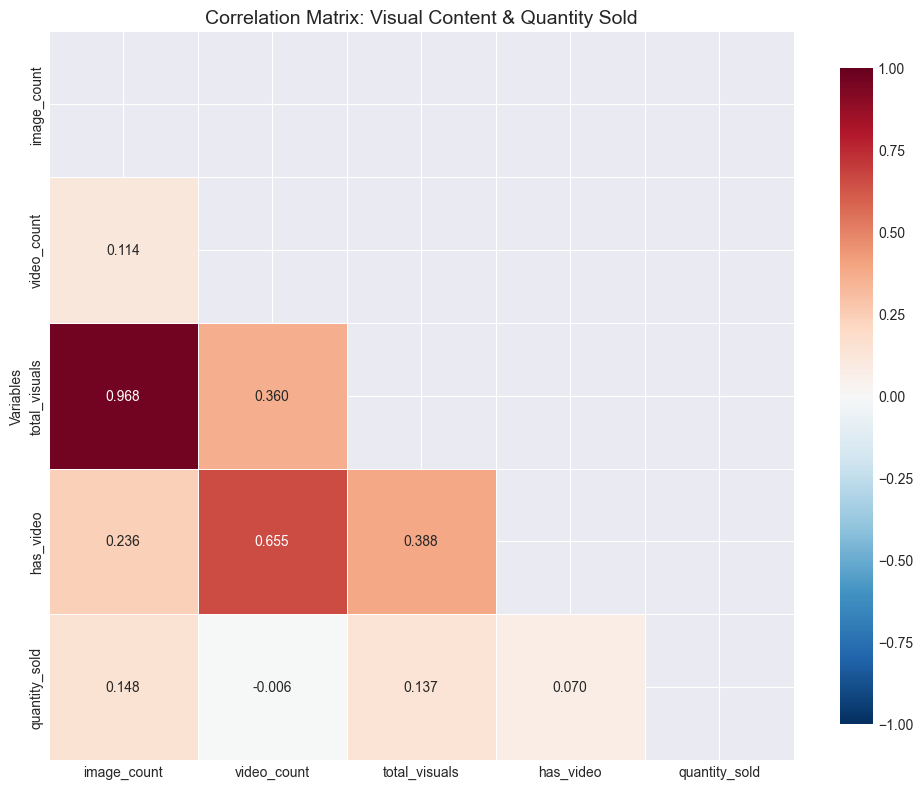

In [8]:
# Các cột cần kiểm tra

cols = ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']

corr_matrix = df_visual[cols].corr()

plt.figure(figsize=(10, 8))

# Che các tam giác trên 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9}
)

plt.title("Correlation Matrix: Visual Content & Quantity Sold", fontsize=14)
plt.ylabel("Variables")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Scatter Plot + Regression Line cho 2 biến**

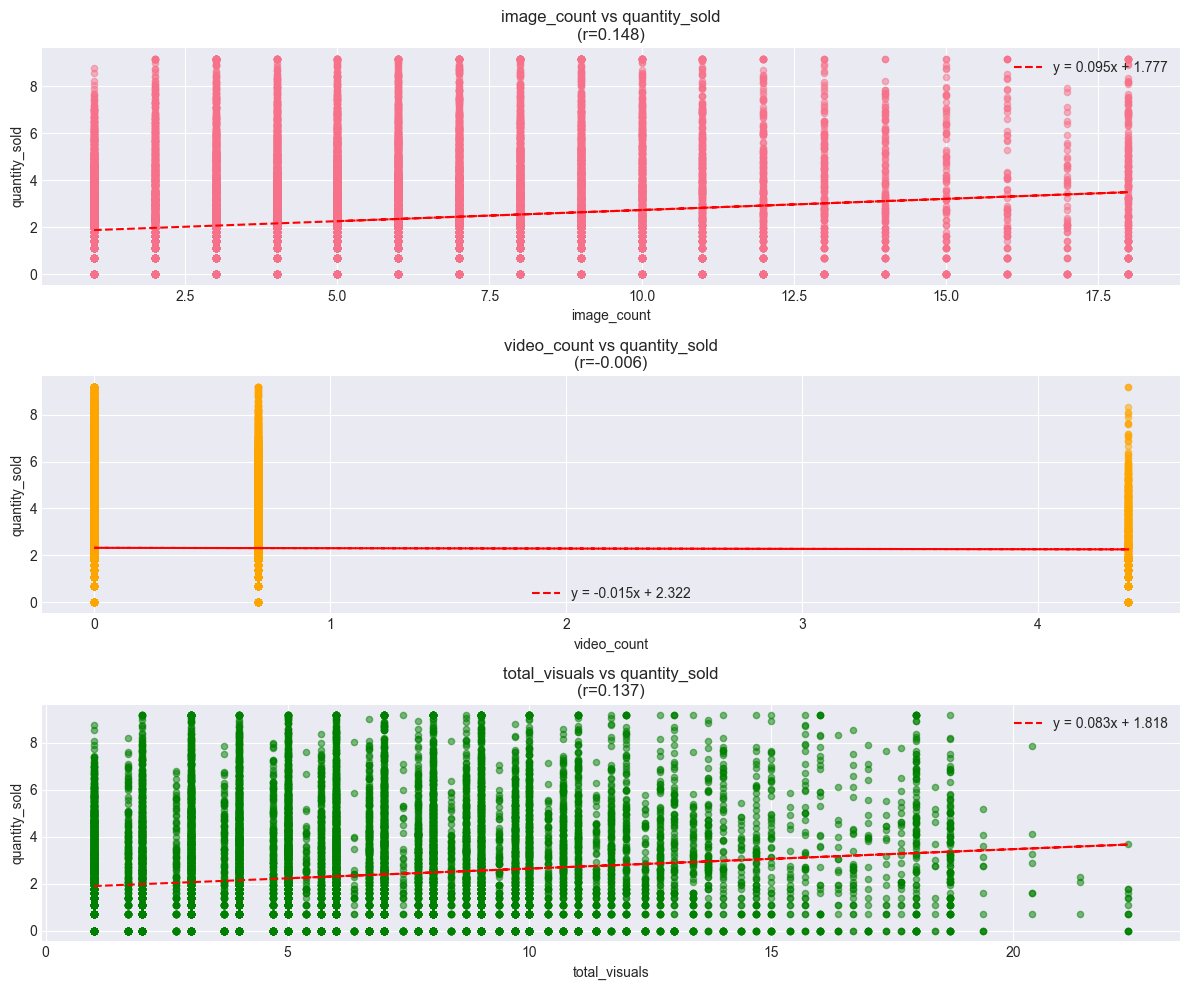

In [9]:
# Scatter plot giữa các biến & quantity_sold

# Ma trận tương quan (chỉ dùng cho tiêu đề biểu đồ)
corr_matrix = df_visual.corr()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Scatter 1: image_count vs quantity_sold
axes[0].scatter(df_visual['image_count'], df_visual['quantity_sold'], alpha=0.5, s=20)
z = np.polyfit(df_visual['image_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[0].plot(df_visual['image_count'], p(df_visual['image_count']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0].set_xlabel('image_count')
axes[0].set_ylabel('quantity_sold')
axes[0].set_title(
    f'image_count vs quantity_sold\n(r={corr_matrix.loc["image_count", "quantity_sold"]:.3f})'
)
axes[0].legend()

# Scatter 2: video_count vs quantity_sold
axes[1].scatter(df_visual['video_count'], df_visual['quantity_sold'],
                   alpha=0.5, s=20, color='orange')
z = np.polyfit(df_visual['video_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[1].plot(df_visual['video_count'], p(df_visual['video_count']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[1].set_xlabel('video_count')
axes[1].set_ylabel('quantity_sold')
axes[1].set_title(
    f'video_count vs quantity_sold\n(r={corr_matrix.loc["video_count", "quantity_sold"]:.3f})'
)
axes[1].legend()

# Scatter 3: total_visuals vs quantity_sold
axes[2].scatter(df_visual['total_visuals'], df_visual['quantity_sold'],
                   alpha=0.5, s=20, color='green')
z = np.polyfit(df_visual['total_visuals'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[2].plot(df_visual['total_visuals'], p(df_visual['total_visuals']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[2].set_xlabel('total_visuals')
axes[2].set_ylabel('quantity_sold')
axes[2].set_title(
    f'total_visuals vs quantity_sold\n(r={corr_matrix.loc["total_visuals", "quantity_sold"]:.3f})'
)
axes[2].legend()



plt.tight_layout()
plt.show()

### **✍️ Nhận xét:**
**1. Insight cho biểu đồ tương quan tổng hợp giữa `image_count`, `video_count`, `total_visuals` và `has_video` với `quantity_sold`:**  
- Biểu đồ cho thấy mối quan hệ giữa nội dung trực quan và lượng bán tồn tại nhưng ở mức **yếu**.   
  
- Số lượng ảnh (r = 0.148) và tổng số nội dung trực quan (r = 0.137) có xu hướng **tương quan thuận nhẹ** với `quantity_sold`, trong khi video cũng có tác động chút ít (r = 0.07) đến lượng sản phẩm bán ra nhưng số lượng video (r = -0.006) lại gần như **không có** mối liên hệ tuyến tính rõ ràng.
  

**Boxplot cho từng vùng giá trị**

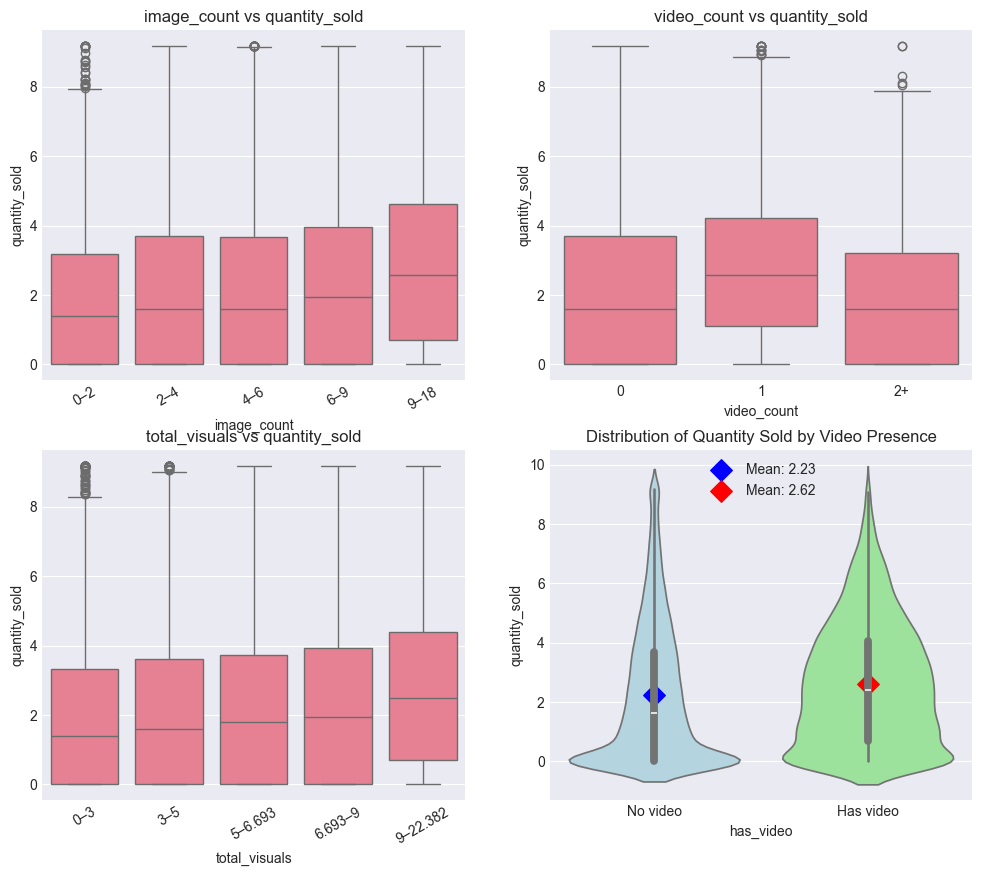

In [10]:
# 2. Boxplot (quantile bins) giữa các biến & quantity_sold
df_box = df_visual.copy()

def relabel_qcut_start0(series: pd.Series, q=5):
    bins = pd.qcut(series, q=q, duplicates="drop")
    intervals = bins.cat.categories

    new_labels = []
    for idx, itv in enumerate(intervals):
        left = itv.left
        right = itv.right

        if idx == 0:
            left = 0

        def fmt(x):
            if abs(x - round(x)) < 1e-9:
                return str(int(round(x)))
            return f"{x:.3f}"

        new_labels.append(f"{fmt(left)}–{fmt(right)}")

    return bins.cat.rename_categories(new_labels)

# Chia bin
# image_count & total_visuals: quantile như bình thường (nhãn bắt đầu từ 0)
df_box["image_bin"] = relabel_qcut_start0(df_box["image_count"], q=5)
df_box["total_bin"] = relabel_qcut_start0(df_box["total_visuals"], q=5)

# video_count: 0 video / 1 video / nhiều video (2+)
df_box["video_bin"] = pd.cut(
    df_box["video_count"],
    bins=[-1, 0, 1, float("inf")],
    labels=["0", "1", "2+"]
)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Boxplot 1: image_count
sns.boxplot(x="image_bin", y="quantity_sold", data=df_box, ax=axes[0, 0])
axes[0, 0].set_xlabel("image_count")
axes[0, 0].set_ylabel("quantity_sold")
axes[0, 0].set_title("image_count vs quantity_sold")
axes[0, 0].tick_params(axis='x', rotation=30)

# Boxplot 2: video_count (3 nhóm)
sns.boxplot(x="video_bin", y="quantity_sold", data=df_box, ax=axes[0, 1])
axes[0, 1].set_xlabel("video_count")
axes[0, 1].set_ylabel("quantity_sold")
axes[0, 1].set_title("video_count vs quantity_sold")
axes[0, 1].tick_params(axis='x', rotation=0)

# Boxplot 3: total_visuals
sns.boxplot(x="total_bin", y="quantity_sold", data=df_box, ax=axes[1, 0])
axes[1, 0].set_xlabel("total_visuals")
axes[1, 0].set_ylabel("quantity_sold")
axes[1, 0].set_title("total_visuals vs quantity_sold")
axes[1, 0].tick_params(axis='x', rotation=30)

# Violin plot: has_video 
sns.violinplot(
    x="has_video",
    y="quantity_sold",
    data=df_visual,
    ax=axes[1, 1],
    palette=["lightblue", "lightgreen"]
)

axes[1, 1].set_xticklabels(["No video", "Has video"])
axes[1, 1].set_title("Distribution of Quantity Sold by Video Presence")

# Mean cho từng nhóm
means = df_visual.groupby("has_video")["quantity_sold"].mean()

# No video mean (x = 0)
axes[1, 1].scatter(
    0, means.iloc[0],
    color="blue", s=120, marker="D",
    label=f"Mean: {means.iloc[0]:.2f}"
)

# Has video mean (x = 1)
axes[1, 1].scatter(
    1, means.iloc[1],
    color="red", s=120, marker="D",
    label=f"Mean: {means.iloc[1]:.2f}"
)

axes[1, 1].legend()



### **✍️ Nhận xét:**
**2. Insight cho biểu đồ Boxplot theo từng miền giá trị giữa `image_count`, `video_count`, `total_visuals` với `quantity_sold`, và Violinplot phân phối lượng sản phẩm bán ra theo 2 nhóm trong `has_video`:**  
- Median `quantity_sold` tăng dần theo số lượng ảnh -> Số lượng ảnh có ảnh hưởng tích cực đến doanh số, đặc biệt từ mốc 6 ảnh trở lên.

- Nhóm có 1 video có trung bình và trung vị của `quantity_sold` đều cao hơn nhóm không có video, trong khi nhóm 2+ video không cải thiện thêm rõ rệt, thậm chí có xu hướng giảm nhẹ -> Chỉ cần 1 video chất lượng là đủ tạo tác động tích cực.

- Median `quantity_sold` tăng đều theo từng khoảng giá trị của `total_visuals`.

- Phân phối theo `has_video` cho thấy sản phẩm có video có mức bán trung bình **cao hơn** so với sản phẩm không có video, tuy nhiên sự chồng lấn lớn giữa hai nhóm cho thấy video **không** tạo ra sự khác biệt đáng kể. Điều này hàm ý rằng nội dung trực quan chỉ đóng vai trò **hỗ trợ** trong quyết định mua hàng, còn hiệu quả bán hàng phụ thuộc chủ yếu vào các yếu tố nền tảng khác như giá, khuyến mãi và độ uy tín của cửa hàng.

**Scatter Plot + Regression Line cho 3 biến**

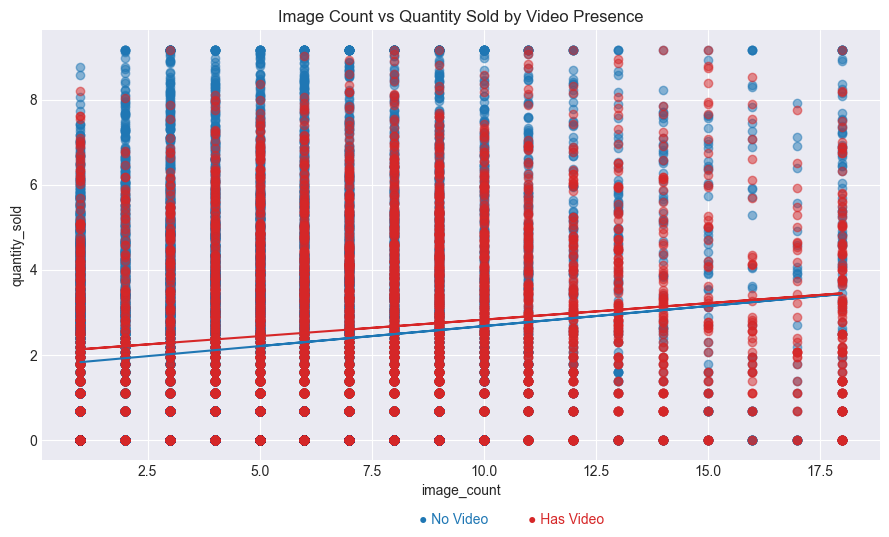

In [11]:
# Scatter plot giữa 3 biến (image_count, quantity_sold, has_video)
df_plot = df[['image_count', 'quantity_sold', 'has_video']].dropna()

df_no = df_plot[df_plot['has_video'] == 0]
df_yes = df_plot[df_plot['has_video'] == 1]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(df_no['image_count'], df_no['quantity_sold'],
            color='tab:blue', alpha=0.5)
plt.scatter(df_yes['image_count'], df_yes['quantity_sold'],
            color='tab:red', alpha=0.5)

# Trend lines
coef_no = np.polyfit(df_no['image_count'], df_no['quantity_sold'], 1)
plt.plot(df_no['image_count'],
         coef_no[0] * df_no['image_count'] + coef_no[1],
         color='tab:blue')

coef_yes = np.polyfit(df_yes['image_count'], df_yes['quantity_sold'], 1)
plt.plot(df_yes['image_count'],
         coef_yes[0] * df_yes['image_count'] + coef_yes[1],
         color='tab:red')

# Labels
plt.xlabel('image_count')
plt.ylabel('quantity_sold')
plt.title('Image Count vs Quantity Sold by Video Presence')

# Chú thích
plt.text(0.45, -0.15, '● No Video',
         transform=plt.gca().transAxes,
         color='tab:blue', fontsize=10)
plt.text(0.58, -0.15, '● Has Video',
         transform=plt.gca().transAxes,
         color='tab:red', fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

### **✍️ Nhận xét:**
**3.  Insight cho biểu đồ tương quan giữa `image_count` vs `quantity_sold` theo sự hiện diện của video:**
- Khi phân tích đồng thời số lượng ảnh và sự hiện diện của video, cả hai nhóm sản phẩm có và không có video đều thể hiện xu hướng tăng nhẹ của lượng bán khi số ảnh tăng

- Độ dốc của các đường hồi quy gần như tương đương cho thấy video không làm thay đổi bản chất mối quan hệ giữa số lượng ảnh và hiệu quả bán hàng, mà chỉ mang lại một mức cải thiện nền nhỏ về lượng bán trung bình

- Ngoài ra, độ phân tán lớn của `quantity_sold` tại cùng một mức `image_count` ở cả hai nhóm cho thấy việc gia tăng nội dung trực quan không đảm bảo hiệu quả bán hàng nếu không đi kèm các yếu tố khác. Kết quả này khẳng định rằng hình ảnh là yếu tố **cần thiết** để hỗ trợ quyết định mua, trong khi video chỉ đóng vai trò **bổ sung** chứ không tạo ra hiệu ứng cộng hưởng mạnh.

**Grouped Bar Graph**

Số cột category one-hot: 22


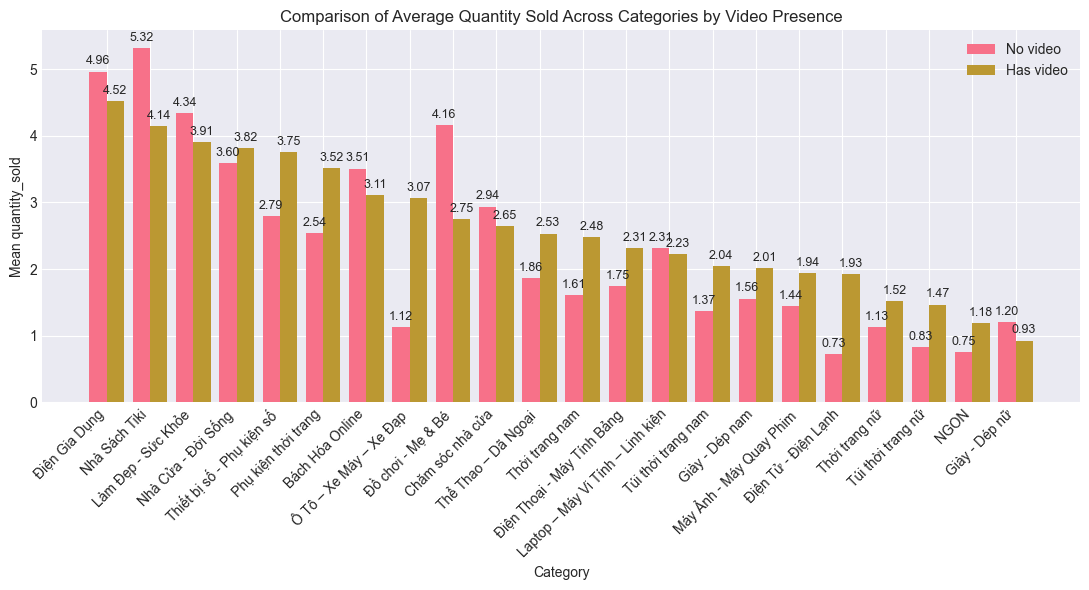

In [12]:
#  1) Lấy tất cả cột one-hot category_root_name_... 
prefix = "category_root_name_"
cat_cols = [c for c in df.columns if c.startswith(prefix)]
print("Số cột category one-hot:", len(cat_cols))

# 2) Suy ra tên category cho từng dòng từ one-hot 
# row_sum: tổng các cột one-hot theo từng dòng
row_sum = df[cat_cols].sum(axis=1)

# idxmax: lấy tên cột có giá trị lớn nhất theo từng dòng
# (giả sử one-hot đúng thì cột = 1 sẽ là max)
cat_col_max = df[cat_cols].idxmax(axis=1)

# Tạo cột category_root_name (bỏ prefix để chỉ còn tên danh mục)
df["category_root_name"] = np.where(
    row_sum > 0,
    cat_col_max.str.replace(prefix, "", regex=False),
    "Unknown"
)

# 3) Tính trung bình quantity_sold theo (category, has_video) 
# has_video: 0 = không có video, 1 = có video
summary = (
    df.groupby(["category_root_name", "has_video"], as_index=False)["quantity_sold"]
      .mean()
)

#  Đưa về bảng dạng pivot: mỗi category có 2 cột mean (no_video, has_video) 
pivot = summary.pivot(
    index="category_root_name",   # mỗi hàng là 1 danh mục
    columns="has_video",          # cột 0/1 tách 2 nhóm video
    values="quantity_sold"        # giá trị là mean quantity_sold
).fillna(0)                       # nhóm nào không có data thì mean = 0 cho dễ vẽ

# Đổi tên cột cho dễ đọc (0 -> no_video, 1 -> has_video)
pivot = pivot.rename(columns={0: "no_video", 1: "has_video"})

# Phòng trường hợp dataset chỉ có 0 hoặc chỉ có 1 (tránh lỗi thiếu cột)
if "no_video" not in pivot.columns:
    pivot["no_video"] = 0.0
if "has_video" not in pivot.columns:
    pivot["has_video"] = 0.0

# 5) Bỏ category "Unknown" không được one-hot khỏi phân tích theo danh mục
pivot = pivot.drop(index="Unknown", errors="ignore")

# 6) Sắp xếp category (ví dụ: theo mean của nhóm có video giảm dần) 
pivot = pivot.sort_values("has_video", ascending=False)

# 7) Vẽ biểu đồ bar chart: mỗi category có 2 cột
categories = pivot.index.tolist()
x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(max(10, len(categories)*0.5), 6))

# Cột cho nhóm "No video"
bars1 = ax.bar(x - width/2, pivot["no_video"].values, width, label="No video")

# Cột cho nhóm "Has video"
bars2 = ax.bar(x + width/2, pivot["has_video"].values, width, label="Has video")

# Gắn nhãn trục + tiêu đề + legend 
ax.set_xlabel("Category")
ax.set_ylabel("Mean quantity_sold")
ax.set_title("Comparison of Average Quantity Sold Across Categories by Video Presence")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend()

# 9) Ghi giá trị mean lên đầu mỗi cột 
def add_labels(bars):
    for b in bars:
        h = b.get_height()
        ax.annotate(
            f"{h:.2f}",
            xy=(b.get_x() + b.get_width()/2, h),
            xytext=(0, 3),             
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()


**3. Insight cho biểu đồ cột thể hiện trung bình `quantity_sold` theo `video presence` ở từng danh mục:**   
- Ở phần lớn các danh mục, các sản phẩm có video thường đạt số lượng bán trung bình **cao hơn** so với các sản phẩm không có video. Điều này cho thấy video đóng vai trò khá tích cực trong việc thu hút sự chú ý và hỗ trợ quyết định mua hàng.
  
- Tác động của video thể hiện rõ hơn ở các danh mục mang tính **trực quan cao** như **Phụ kiện thời trang, Thiết bị số – Phụ kiện số, Ô tô - Xe máy - Xe đạp**. Trong các danh mục này, video giúp người mua hình dung rõ hơn về kiểu dáng, tính năng và cách sử dụng sản phẩm, từ đó làm tăng khả năng mua.
  
- Ở một số danh mục như **Nhà Sách Tiki và Điện Gia Dụng**, tác động của video hầu như **kém**. Điều này cho thấy với các sản phẩm mang tính tiêu chuẩn hoặc quen thuộc, video không mang lại nhiều giá trị bổ sung so với hình ảnh và mô tả cơ bản.

- Ở một số danh mục có **tổng sản phẩm trung bình bán ra cao** như Nhà Sách Tiki và Làm đẹp – Sức khỏe vẫn đạt **mức bán trung bình cao hơn** khi không có video, trong khi các nhóm có **tổng sản phẩm bán ra trung bình thấp hoặc vừa** như Thời trang nam và Điện Tử - Điện Lạnh lại cần có **sự góp mặt của video để có lượng bán ra cao hơn**. Từ đó phản ánh nhu cầu ổn định và mức độ tin tưởng sẵn có của người tiêu dùng đối với các sản phẩm có mức bán ra cao.

### **📌Nhận định chung:**
- **Nội dung trực quan** (hình ảnh, video) trên Tiki có **tác động tích cực** nhưng **không mang tính quyết định** đối với số lượng bán ra. Điều này phù hợp với thực tế Tiki là sàn thiên về mua sắm định hướng nhu cầu và độ tin cậy, thay vì mua sắm cảm xúc thuần túy.

- **Tác động của video phụ thuộc mạnh vào danh mục sản phẩm**. Ở các danh mục cần **tính trực quan cao**, video mang lại **lợi ích rõ ràng** hơn do người mua cần biết kiểu dáng sản phẩm và cách sản phẩm hoạt động. Ngược lại, với các danh mục mang tính **tiêu chuẩn và quen thuộc** thì quyết định mua hàng chủ yếu **dựa vào các yếu tố khác** như lượt đánh giá, độ tin cậy của shop, giá cả,.... Điều này khiến vai trò của video trở nên **hạn chế**.

### **🚀 Chiến lược đề xuất:**
- **Người bán** nên ưu tiên video cho các danh mục có tính **trực quan cao** (thời trang, phụ kiện, điện tử), nơi video giúp **giảm bất định thông tin** và **tăng trải nghiệm người dùng**. Với các danh mục **tiêu chuẩn** như sách hoặc đồ gia dụng cơ bản, video **không cần thiết** cho mọi sản phẩm. Ngoài ra, các cửa hàng cũng nên biết tăng cường tài nguyên hình ảnh và duy trì tổng số lượng trực quan để vừa giúp khách hàng hiểu rõ hơn về sản phẩm vừa tránh gây quá tải thông tin (chỉ thông tin đến người dùng 1 video là đủ và những hình ảnh cần thiết nhưng đáp ứng đủ nhu cầu tìm hiểu sản phẩm).

- **Tiki** nên tập trung khuyến khích hoặc hỗ trợ video ở các danh mục có lợi ích rõ rệt từ **nội dung trực quan**, thay vì áp dụng chung cho toàn sàn nhằm giúp người bán đưa ra chiến lược nên **tăng hay giảm chi phí** đầu tư cho video và tập trung vào các khía cạnh khác như chất lượng sản phẩm hay chiến lược giảm giá để tăng doanh số.

## **3️⃣ Giá sản phẩm (`price`) và tỷ lệ giảm giá (`discount_rate`) ảnh hưởng như thế nào đến số lượng bán ra (`quantity_sold`)?**  
 

**Mục tiêu:** 
- Phân tích mối quan hệ giữa giá sản phẩm, tỷ lệ giảm giá và số lượng bán ra. Chúng ta sẽ sử dụng các phương pháp thống kê mô tả và trực quan hóa dữ liệu để trả lời câu hỏi này. 
  
- Thống kê xem discount_rate thì có bán được nhiều hơn so với những không discount trong cùng 1 danh mục

**Cách thức thực hiện:** Để trả lời câu hỏi này, nhóm em sẽ phân tích mối quan hệ giữa giá sản phẩm (`price`), tỷ lệ giảm giá (`discount_rate`) và số lượng bán ra (`quantity_sold`) bằng cách sử dụng các biểu đồ trực quan hóa dữ liệu và các phương pháp thống kê. Chúng ta sẽ xem xét các yếu tố sau:
1. **Phân tích mô tả**: Tính toán các thống kê mô tả như trung bình, trung vị, độ lệch chuẩn của các biến `price`, `discount_rate` và `quantity_sold` để hiểu rõ hơn về phân phối dữ liệu.  
  
2. **Biểu đồ Heatmap**: Vẽ biểu đồ heatmap để quan sát mối quan hệ giữa `price` và `quantity_sold`, cũng như giữa `discount_rate` và `quantity_sold` tổng quát với toàn bộ sản phẩm.  
  
3. **Biểu đồ scatter (Scatter Plot)**: Vẽ biểu đồ phân tán để quan sát mối quan hệ giữa `price` và `quantity_sold` theo nhóm danh mục kèm **đường xu hướng**.  
  
4. **Biểu đồ cột (Bar Chart)**: So sánh số lượng bán ra trung bình giữa các nhóm sản phẩm có và không có giảm giá trong cùng một danh mục.  
  
5. **Kiểm định thống kê**: Sử dụng các phương pháp kiểm định thống kê như hồi quy tuyến tính để xác định mức độ ảnh hưởng của `price` và `discount_rate` đến `quantity_sold` theo từng nhóm danh mục.

In [13]:
df = pd.read_csv("../data/processed/data_before_reduction.csv")
df.head()

,product_id,product_name,product_url,category_id,category_name,category_root_name,price,original_price,discount_rate,quantity_sold,...,origin,store_id,store_name,store_review_count,total_follower,is_official,cancel_by_seller_rate,cancel_by_seller_rate_status,return_rate,return_rate_status
0,276641167,Xe máy Honda Vision 2025 Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-cao-c...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.359364,0.0,3.091042,...,"Japan, Vietnam",18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal
1,276626995,Xe Máy Honda Vision 2025 - Phiên Bản Thể Thao,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.496508,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal
2,276626834,Xe Máy Honda Vision 2025 - Phiên Bản Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,3.258097,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal
3,276626812,Xe máy Honda Vision 2025 Đặc Biệt,https://tiki.vn/xe-may-honda-vision-2025-dac-b...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.370830,0.0,2.772589,...,"Japan, Vietnam",18792.0,HEAD Phát Tiến,8.469682,8.615771,0.0,0.0,normal,0.0,normal
4,276626642,Xe Máy Honda Vision 2025 - Phiên Bản Cao Cấp,https://tiki.vn/xe-may-honda-vision-2025-phien...,8597,Xe máy,Ô Tô – Xe Máy – Xe Đạp,17.343018,17.366908,0.0,2.833213,...,Vietnam,180553.0,Honda ủy nhiệm Hoàng Việt,6.824374,7.725771,0.0,0.0,normal,0.0,normal


In [14]:
# 1. Phân tích mô tả
desc = df[['price', 'discount_rate', 'quantity_sold']].describe()
print("Mô tả thống kê (với price và quantity_sold đã Log Transform) :")
display(desc)

Mô tả thống kê (với price và quantity_sold đã Log Transform) :


,price,discount_rate,quantity_sold
count,19811.000000,19811.000000,19811.000000
mean,12.594566,9.004291,2.317290
std,1.596829,13.816046,2.299663
min,9.546884,0.000000,0.000000
25%,11.532738,0.000000,0.000000
50%,12.345839,0.000000,1.791759
75%,13.290418,20.000000,3.784190
max,17.343018,52.000000,9.169977


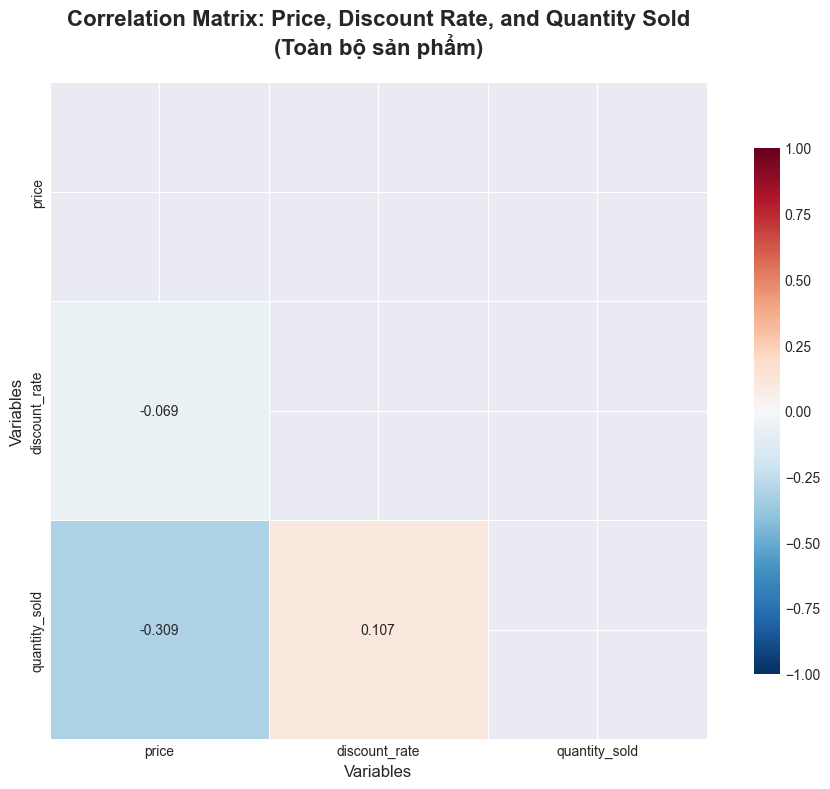

In [15]:
# 2. Vẽ heatmap tương quan giữa 3 biến với toàn bộ sản phẩm
columns_for_corr = ['price', 'discount_rate', 'quantity_sold']
corr_matrix = df[columns_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))

# Tạo mask để chỉ hiện nửa dưới của heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,  # Thêm mask để chỉ hiện nửa dưới
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r',  # Red-Blue colormap
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Price, Discount Rate, and Quantity Sold\n(Toàn bộ sản phẩm)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

**🔍 Nhận định sơ bộ**: 

Dựa trên Heatmap trên và hệ số tương quan Spearman, ta thấy:
- Có một mối quan hệ nghịch giữa giá sản phẩm (`price`) và số lượng bán ra (`quantity_sold`), nghĩa là khi giá sản phẩm tăng thì số lượng bán ra có xu hướng giảm.  
  
- Tỷ lệ giảm giá (`discount_rate`) có mối quan hệ thuận với số lượng bán ra, tức là khi tỷ lệ giảm giá tăng thì số lượng bán ra cũng tăng theo.   
  
→ Mặc dù vậy, để có cái nhìn chính xác hơn, chúng ta cần phân tích sâu hơn qua các biểu đồ scatter và kiểm định thống kê để xác định mức độ ảnh hưởng cụ thể của từng yếu tố đến số lượng bán ra trong từng nhóm danh mục sản phẩm. 

-> Phân chia danh mục theo mức độ tương quan:
- Tương quan khá mạnh (|r| >= 0.3): 10 danh mục
- Tương quan yếu (|r| < 0.3): 13 danh mục

🔵 DANH MỤC CÓ TƯƠNG QUAN KHÁ MẠNH (|r| >= 0.3):
   • Điện Tử - Điện Lạnh: r = -0.626
   • Laptop – Máy Vi Tính – Linh kiện: r = -0.604
   • Ô Tô – Xe Máy – Xe Đạp: r = -0.525
   • Thể Thao – Dã Ngoại: r = -0.471
   • Túi thời trang nam: r = -0.423
   • Thiết bị số - Phụ kiện số: r = -0.348
   • Giày - Dép nam: r = -0.341
   • Giày - Dép nữ: r = -0.328
   • Phụ kiện thời trang: r = -0.301
   • Thời trang nam: r = -0.301



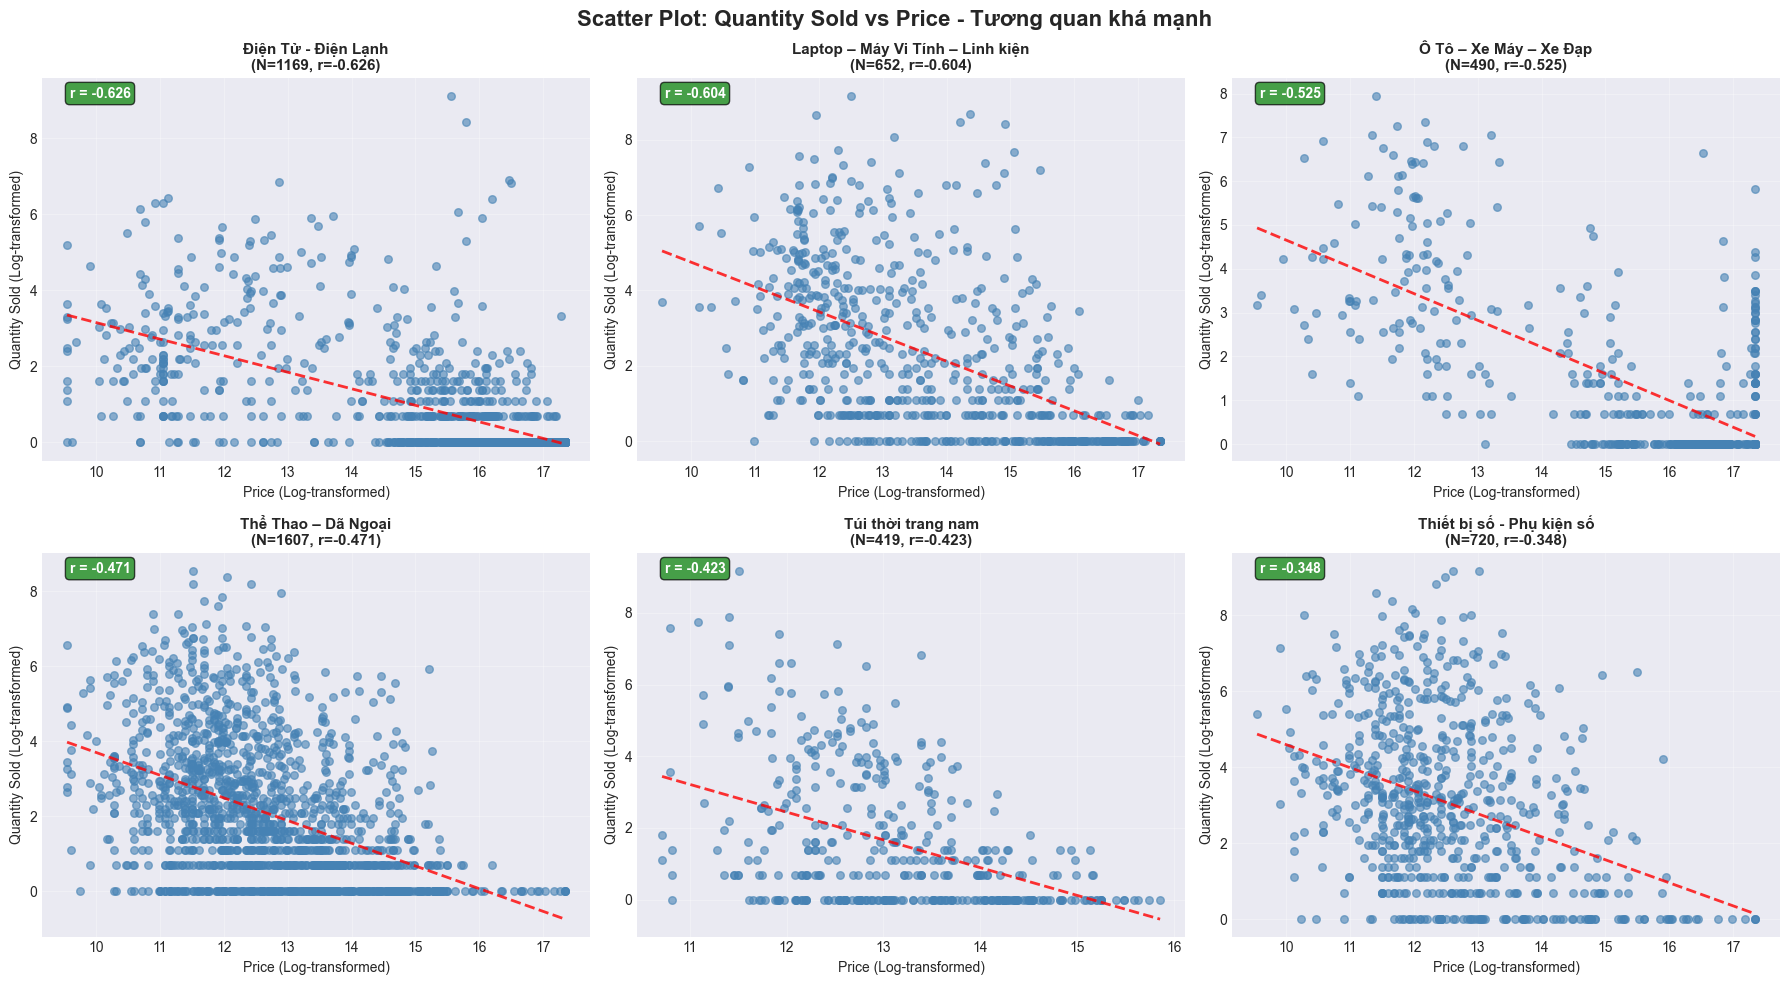

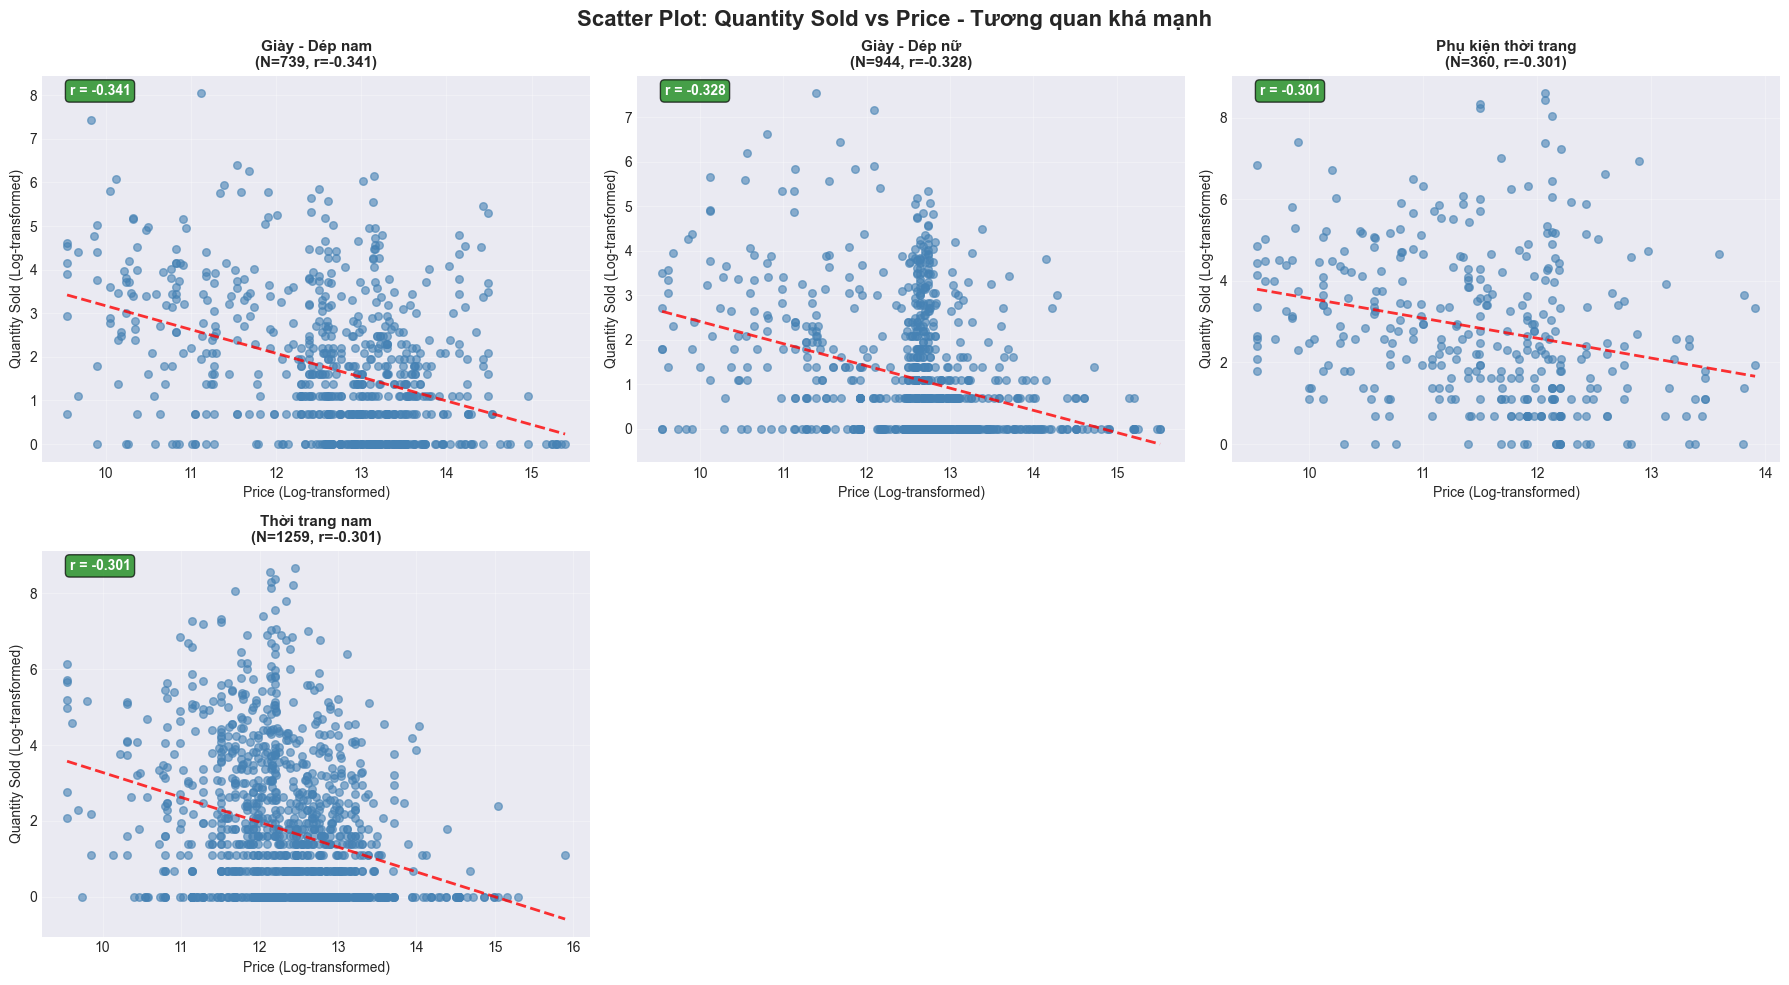

🟡 DANH MỤC CÓ TƯƠNG QUAN YẾU (|r| < 0.3):
   • Máy Ảnh - Máy Quay Phim: r = -0.299
   • Balo và Vali: r = -0.241
   • Nhà Cửa - Đời Sống: r = -0.239
   • NGON: r = -0.221
   • Thời trang nữ: r = -0.217
   • Làm Đẹp - Sức Khỏe: r = -0.204
   • Bách Hóa Online: r = -0.166
   • Điện Thoại - Máy Tính Bảng: r = -0.078
   • Chăm sóc nhà cửa: r = -0.061
   • Túi thời trang nữ: r = -0.033
   • Điện Gia Dụng: r = 0.023
   • Nhà Sách Tiki: r = 0.005
   • Đồ chơi - Mẹ & Bé: r = 0.001



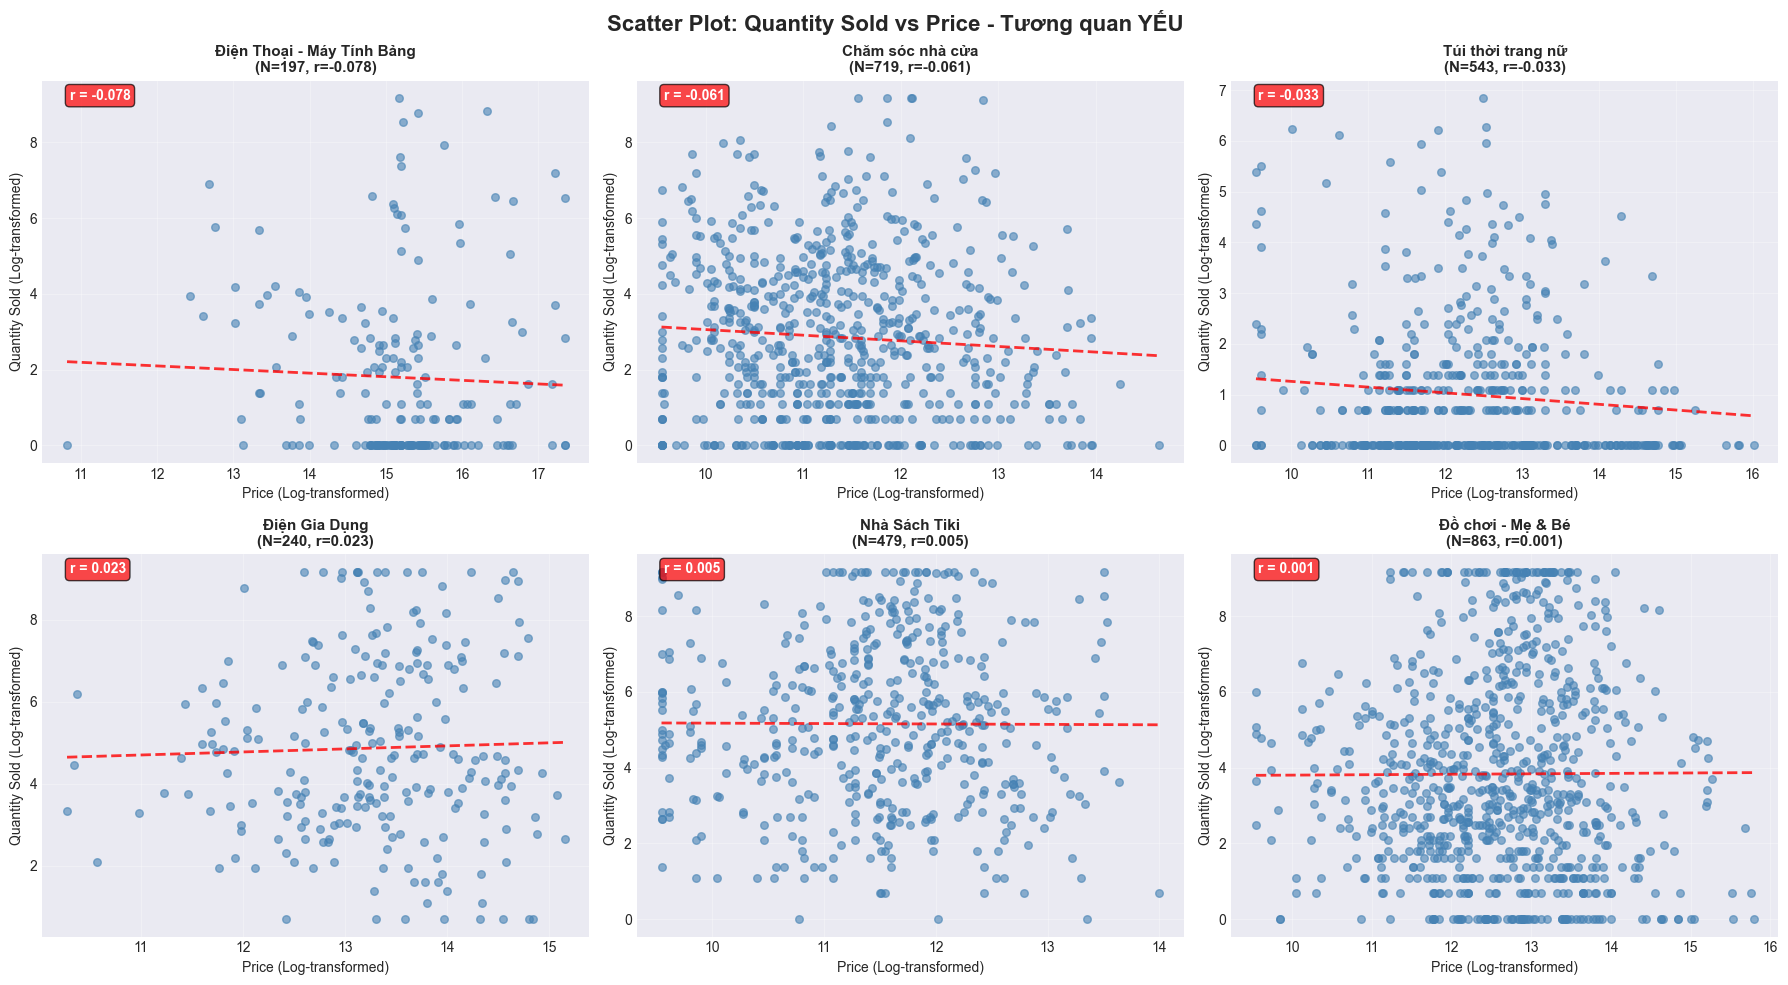

In [16]:
# Lọc các danh mục có đủ dữ liệu
categories = [cat for cat in df['category_root_name'].unique() 
              if len(df[df['category_root_name'] == cat]) > 30]

# Tính correlation cho từng danh mục để phân loại
category_correlations = []
for category in categories:
    subset = df[df['category_root_name'] == category]
    corr = subset['price'].corr(subset['quantity_sold'], method='spearman')
    category_correlations.append({
        'category': category,
        'correlation': corr,
        'count': len(subset)
    })

# Sắp xếp theo mức độ tương quan (từ mạnh đến yếu)
category_correlations = sorted(category_correlations, key=lambda x: abs(x['correlation']), reverse=True)

# Phân chia thành 2 nhóm: correlation mạnh và yếu
strong_corr_threshold = 0.3  # Ngưỡng phân chia
strong_correlations = [item for item in category_correlations if abs(item['correlation']) >= strong_corr_threshold]
weak_correlations = [item for item in category_correlations if abs(item['correlation']) < strong_corr_threshold]

print(f"-> Phân chia danh mục theo mức độ tương quan:")
print(f"- Tương quan khá mạnh (|r| >= {strong_corr_threshold}): {len(strong_correlations)} danh mục")
print(f"- Tương quan yếu (|r| < {strong_corr_threshold}): {len(weak_correlations)} danh mục")
print()

def plot_category_batch(category_data, title_prefix, charts_per_batch=6):
    """
    Hàm vẽ scatter plot cho một batch các danh mục
    """
    n_categories = len(category_data)
    
    # Tính số batch cần thiết
    n_batches = math.ceil(n_categories / charts_per_batch)
    
    for batch_idx in range(n_batches):
        start_idx = batch_idx * charts_per_batch
        end_idx = min(start_idx + charts_per_batch, n_categories)
        batch_categories = category_data[start_idx:end_idx]
        
        # Thiết lập grid (2 hàng x 3 cột cho mỗi batch)
        n_plots = len(batch_categories)
        n_cols = 3
        n_rows = 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
        axes = axes.flatten()
        
        # Vẽ scatter plot cho từng danh mục trong batch
        for i, item in enumerate(batch_categories):
            category = item['category']
            subset = df[df['category_root_name'] == category]
            
            axes[i].scatter(subset['price'], subset['quantity_sold'], 
                           alpha=0.6, s=30, color='steelblue')
            
            # Vẽ đường xu hướng (trendline)
            if len(subset) > 1:
                z = np.polyfit(subset['price'], subset['quantity_sold'], 1)
                p = np.poly1d(z)
                axes[i].plot(subset['price'].sort_values(), p(subset['price'].sort_values()), 
                            "r--", alpha=0.8, linewidth=2, label='Trend')
            
            # Thiết lập title với thông tin chi tiết
            corr = item['correlation']
            axes[i].set_title(f'{category}\n(N={len(subset)}, r={corr:.3f})', 
                             fontsize=11, fontweight='bold')
            axes[i].set_xlabel('Price (Log-transformed)', fontsize=10)
            axes[i].set_ylabel('Quantity Sold (Log-transformed)', fontsize=10)
            axes[i].grid(True, alpha=0.3)
            
            # Hiển thị correlation với màu sắc phù hợp
            color = 'green' if abs(corr) >= 0.3 else 'orange' if abs(corr) >= 0.1 else 'red'
            axes[i].text(0.05, 0.95, f'r = {corr:.3f}', 
                        transform=axes[i].transAxes, 
                        bbox=dict(boxstyle='round', facecolor=color, alpha=0.7),
                        fontsize=10, fontweight='bold', color='white')
        
        # Xóa các subplot thừa
        for j in range(n_plots, len(axes)):
            fig.delaxes(axes[j])
        
        # Thiết lập title cho từng batch
        batch_title = f'{title_prefix}'
        if n_batches == 1:
            batch_title = title_prefix
            
        plt.suptitle(batch_title, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Vẽ các danh mục có tương quan mạnh
if strong_correlations:
    print("🔵 DANH MỤC CÓ TƯƠNG QUAN KHÁ MẠNH (|r| >= 0.3):")
    for item in strong_correlations:
        print(f"   • {item['category']}: r = {item['correlation']:.3f}")
    print()
    
    plot_category_batch(strong_correlations, 
                       "Scatter Plot: Quantity Sold vs Price - Tương quan khá mạnh")

# Vẽ các danh mục có tương quan yếu
if weak_correlations:
    print("🟡 DANH MỤC CÓ TƯƠNG QUAN YẾU (|r| < 0.3):")
    for item in weak_correlations:
        print(f"   • {item['category']}: r = {item['correlation']:.3f}")
    print()
    
    plot_category_batch(weak_correlations[7:], 
                       "Scatter Plot: Quantity Sold vs Price - Tương quan YẾU")

**🧠 Nhận định**:
- Đa phần các danh mục sản phẩm đều cho thấy mối quan hệ nghịch giữa giá sản phẩm và số lượng bán ra, dựa vào đường xu hướng chếch xuống dưới trong biểu đồ scatter plot.  
  
- Một vài danh mục có thể không tuân theo xu hướng này mà có đường xu hướng nằm ngang. Điều này có thể do đặc thù của sản phẩm hoặc các yếu tố khác ảnh hưởng đến quyết định mua hàng của khách hàng. Các danh mục đó bao gồm: **Túi thời trang nữ, Chăm sóc nhà cửa, Nhà sách Tiki, Điện thoại - Máy tính bảng, Đồ chơi - Mẹ & Bé, Điện Gia Dụng**

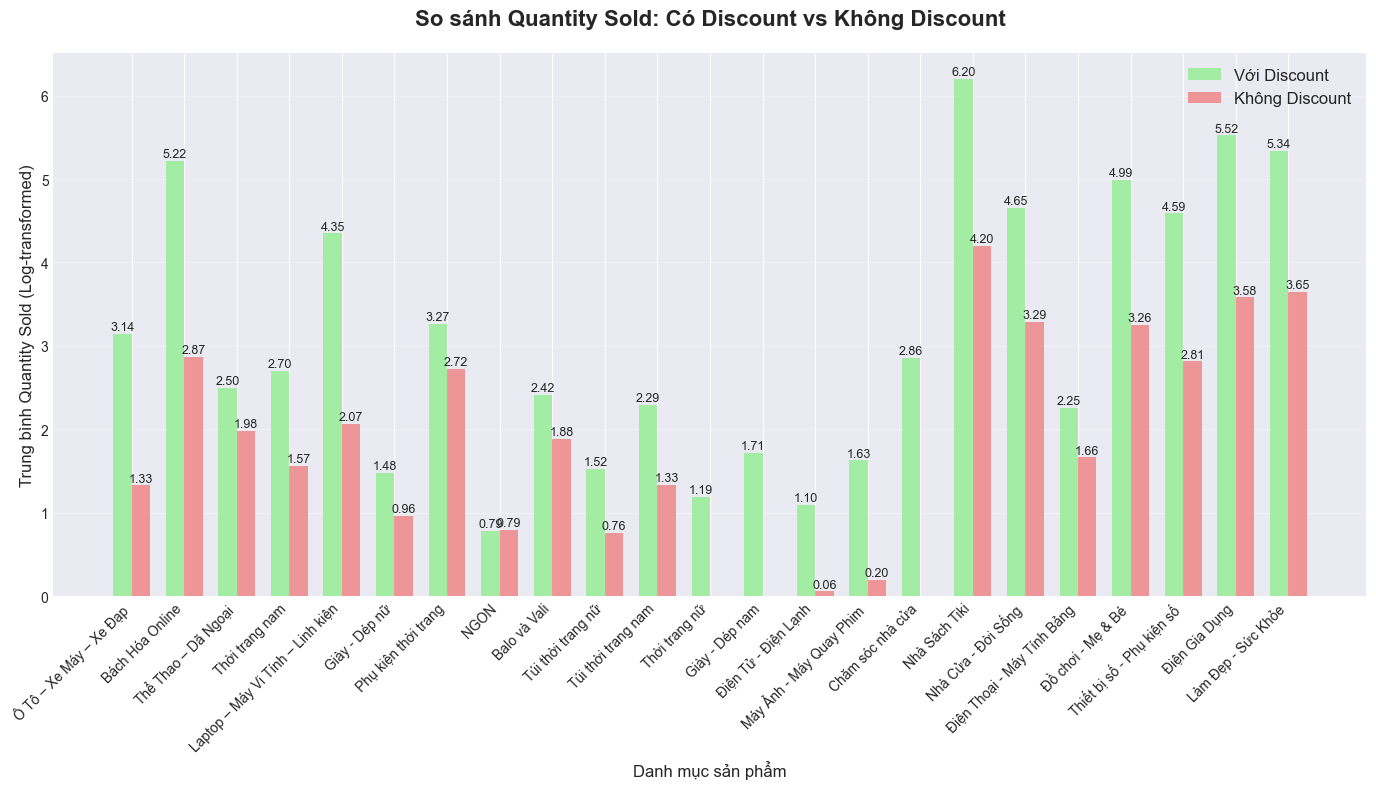

In [17]:
# 4. Vẽ bar plot so sánh có discount và không có discount
# Tạo biến nhị phân cho discount
df['has_discount'] = df['discount_rate'] > 0

# Tính toán cho từng danh mục
categories = [cat for cat in df['category_root_name'].unique() 
              if len(df[df['category_root_name'] == cat]) > 30]

comparison_data = []
for category in categories:
    subset = df[df['category_root_name'] == category]
    
    # Tính trung bình quantity_sold cho có discount và không có discount
    with_discount = subset[subset['has_discount']]['quantity_sold'].mean()
    without_discount = subset[~subset['has_discount']]['quantity_sold'].mean()
    
    comparison_data.append({
        'Category': category,
        'Với Discount': with_discount,
        'Không Discount': without_discount,
        'Chênh lệch': with_discount - without_discount
    })

comparison_df = pd.DataFrame(comparison_data)

# Vẽ bar plot so sánh
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(14, 8))
bars1 = plt.bar(x - width/2, comparison_df['Với Discount'], width, 
               label='Với Discount', color='lightgreen', alpha=0.8)
bars2 = plt.bar(x + width/2, comparison_df['Không Discount'], width, 
               label='Không Discount', color='lightcoral', alpha=0.8)

plt.title('So sánh Quantity Sold: Có Discount vs Không Discount', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Trung bình Quantity Sold (Log-transformed)', fontsize=12)
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    plt.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01,
             f'{comparison_df.iloc[i]["Với Discount"]:.2f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.01,
             f'{comparison_df.iloc[i]["Không Discount"]:.2f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**🧠 Nhận định**:
- Từ biểu đồ grouped bar chart, ta thấy rằng trong hầu hết các danh mục sản phẩm, nhóm sản phẩm có giảm giá (`discount_rate` > 0) thường có *số lượng bán ra trung bình cao hơn nhiều* so với nhóm không giảm giá (`discount_rate` = 0). Điều này cho thấy rằng việc áp dụng giảm giá có thể thúc đẩy doanh số bán hàng trong nhiều danh mục sản phẩm.  
  
- Một vài nhóm danh mục thậm chí luôn trong tình trạng giảm giá hoặc gần như vậy, điều này có thể phản ánh chiến lược giá của nhà bán lẻ trong các danh mục này.  
  
- Quan sát được chỉ có danh mục **NGON** là số lượng bán ra trung bình bằng nhau giữa 2 nhóm có giảm giá và không giảm giá.

In [18]:
# 5. Kiểm định thống kê tương quan Spearman giữa price, discount_rate và quantity_sold cho từng danh mục
results = []
for category in categories:
    subset = df[df['category_root_name'] == category]
    
    if len(subset) < 30:
        continue  # Bỏ qua các danh mục có ít hơn 30 sản phẩm
    
    # Tương quan giữa price và quantity_sold
    corr_price_qty, p_value_price_qty = stats.spearmanr(subset['price'], subset['quantity_sold'])
    
    # Tương quan giữa discount_rate và quantity_sold
    corr_discount_qty, p_value_discount_qty = stats.spearmanr(subset['discount_rate'], subset['quantity_sold'])
    
    results.append({
        'Category': category,
        'Corr Price-Qty': corr_price_qty,
        'P-value Price-Qty': p_value_price_qty,
        'Corr Discount-Qty': corr_discount_qty,
        'P-value Discount-Qty': p_value_discount_qty
    })
results_df = pd.DataFrame(results)

# Tạo function để tô màu những p-value > 0.1
def highlight_non_significant(val):
    """
    Tô màu đỏ nhạt cho các p-value > 0.1 (không có ý nghĩa thống kê)
    """
    if isinstance(val, (int, float)):
        if val > 0.1:
            # Chữ đen nên xanh dương
            return 'background-color: #ff9999; color: #000000 ;font-weight: bold';  
        else:
            return ''
    return ''

print("\nKết quả kiểm định thống kê tương quan Spearman theo từng danh mục:")
print("(Các ô có màu đỏ nhạt là p-value > 0.1 - không có ý nghĩa thống kê)")

# Áp dụng styling cho DataFrame
styled_df = results_df[9:].round(3).style.applymap(highlight_non_significant, 
                                               subset=['P-value Price-Qty', 'P-value Discount-Qty'])
display(styled_df)


Kết quả kiểm định thống kê tương quan Spearman theo từng danh mục:
(Các ô có màu đỏ nhạt là p-value > 0.1 - không có ý nghĩa thống kê)


,Category,Corr Price-Qty,P-value Price-Qty,Corr Discount-Qty,P-value Discount-Qty
9,Túi thời trang nữ,-0.033000,0.447000,0.274000,0.000000
10,Túi thời trang nam,-0.423000,0.000000,0.195000,0.000000
11,Thời trang nữ,-0.217000,0.000000,0.378000,0.000000
12,Giày - Dép nam,-0.341000,0.000000,0.111000,0.002000
13,Điện Tử - Điện Lạnh,-0.626000,0.000000,0.411000,0.000000
14,Máy Ảnh - Máy Quay Phim,-0.299000,0.000000,0.352000,0.000000
15,Chăm sóc nhà cửa,-0.061000,0.101000,0.144000,0.000000
16,Nhà Sách Tiki,0.005000,0.913000,0.455000,0.000000
17,Nhà Cửa - Đời Sống,-0.239000,0.000000,0.291000,0.000000
18,Điện Thoại - Máy Tính Bảng,-0.078000,0.277000,0.027000,0.709000


### **📌 Nhận định chung và kiểm định**:
- Qua các phân tích và biểu đồ trực quan hóa dữ liệu, chúng ta có thể kết luận rằng cả giá sản phẩm (price) và tỷ lệ giảm giá (discount_rate) đều ảnh hưởng đáng kể đến số lượng bán ra (quantity_sold) trong hầu hết các danh mục sản phẩm.  
  
- Việc giảm giá sản phẩm thường dẫn đến tăng số lượng bán ra, trong khi giá sản phẩm cao hơn thường làm giảm số lượng bán ra. Tuy nhiên, mức độ ảnh hưởng của từng yếu tố có thể khác nhau tùy thuộc vào đặc thù của từng danh mục sản phẩm.  
  
- Dựa vào các kết quả kiểm định thống kê, chúng ta có thể xác nhận rằng cả hai yếu tố price và discount_rate đều có ảnh hưởng đáng kể đến quantity_sold trong hầu hết các danh mục sản phẩm, với mức ý nghĩa thống kê phù hợp (p-value < 0.1).

### ***💡Một vài insight quan sát được***:
- Danh mục duy nhất có `quantity_sold` hoàn toàn không bị ảnh hưởng bởi `price` và `discount_rate` thường là **Điện thoại - Máy tính bảng**. Người dùng sẵn lòng chi trả cao cho các sản phẩm trong danh mục này bất kể giá cả hay giảm giá.  
  
- Các danh mục như **Túi thời trang nữ, Nhà sách Tiki, Đồ chơi - Mẹ & Bé, Điện Gia Dụng** có `quantity_sold` không ảnh hưởng bởi `price` nhưng vẫn bị ảnh hưởng bởi `discount_rate`. Điều này cho thấy rằng người tiêu dùng trong các danh mục này có thể nhạy cảm hơn với các chương trình giảm giá so với giá cả sản phẩm. Cho thấy nếu cùng một mức giá giữa các shop thì shop nào có giảm giá sẽ bán được nhiều hơn.  
  
- Cần chú ý các danh mục bị ảnh hưởng sâu sắc bởi `price` với hệ số tương quan âm cao như **Laptop – Máy Vi Tính, Điện Tử - Điện Lạnh và Ô Tô - Xe Máy** chứng tỏ người tiêu dùng trong các danh mục này rất nhạy cảm với giá cả, và việc tăng giá có thể dẫn đến giảm mạnh số lượng bán ra.  
  
- Các danh mục còn lại đều tuân theo quy luật và cho thấy `quantity_sold` bị ảnh hưởng bởi cả `price` và `discount_rate`, với xu hướng chung là giá cao làm giảm số lượng bán ra, trong khi giảm giá làm tăng số lượng bán ra.

### **🚀 Chiến lược đề xuất:**
- Đối với các dạnh mục **không nhạy cảm với cả giá cả và giảm giá**, nhà bán lẻ có thể duy trì chiến lược giá hiện tại mà không cần điều chỉnh nhiều về giá cả hay giảm giá, tập trung vào các yếu tố khác như chất lượng sản phẩm và dịch vụ khách hàng để tăng doanh số bán hàng.  
  
- Đối với các danh mục **chỉ nhạy cảm với giá cả**, nhà bán lẻ nên cân nhắc kỹ lưỡng trước khi tăng giá sản phẩm để tránh giảm doanh số bán hàng. Nên tập trung vào việc duy trì mức giá cạnh tranh.  
  
- Đối với các danh mục **chỉ nhạy cảm với giảm giá** , nhà bán lẻ nên tập trung vào việc triển khai các chương trình giảm giá hấp dẫn để thúc đẩy doanh số bán hàng. Không nên quá chú trọng vào việc điều chỉnh giá cả.  
  
- Đối với các danh mục **nhạy cảm với cả giá cả và giảm giá**, nhà bán lẻ nên áp dụng chiến lược giá linh hoạt, kết hợp giữa việc duy trì mức giá hợp lý và triển khai các chương trình giảm giá định kỳ để tối ưu hóa doanh số bán hàng. 

## **4️⃣ Liệu việc trở thành "Cửa hàng Chính hãng (`is_official`)" có thực sự mang lại lượng bán hàng (`quantity_sold`) vượt trội hơn so với các cửa hàng thông thường trên cùng một ngành hàng không?**  


**Mục tiêu**: Xác định rằng liệu việc trở thành "Cửa hàng Chính hãng (`is_official`)" có có thực sự mang lại lượng bán hàng (`quantity_sold`) vượt trội hơn so với các cửa hàng thông thường trên cùng một ngành hàng không?  
  
**Lợi ích**: 
- Giúp nhà bán hàng đánh giá chính xác mức độ tác động của danh hiệu "Chính hãng" đến tâm lý lựa chọn của khách hàng trên Tiki.  
  
- Giúp các cửa hàng quyết định có nên đầu tư chi phí để nâng cấp lên mô hình Chính hãng nhằm chiếm lĩnh thị phần hay không.  
  
- Giúp các Shop thường nhận diện được khoảng trống thị trường để cạnh tranh bằng sự linh hoạt hoặc các mặt hàng ngách mà Shop chính hãng chưa phủ tới.    
- Hiểu rõ cách thức danh hiệu này giúp giảm thiểu rào cản tâm lý về hàng giả, hàng nhái, từ đó thúc đẩy tỷ lệ chuyển đổi đơn hàng.  

**Cách thức thực hiện**: 
1. Gom nhóm dữ liệu theo `category_group` và `is_official`.
    
2. Sau đó tính toán Lượng bán trung vị (median) để loại bỏ sai số từ các shop cực lớn. 
    
3. Sử dụng biểu đồ cột kết hợp thang đo Logarit để quan sát sự chênh lệch rõ rệt ở cả những ngành hàng có doanh số thấp.


In [19]:
# Đọc dữ liệu
df = pd.read_csv("../data/processed/data_processed.csv")

In [20]:
# Gom nhóm dữ liệu theo `category_group` và `is_official`.

# Lấy danh sách các cột One-hot encoding của danh mục gốc (bắt đầu bằng 'category_root_name_')
category_cols = [c for c in df.columns if c.startswith("category_root_name_")]

# Chuyển đổi từ dạng One-hot về lại một cột duy nhất chứa tên danh mục
df["category"] = (
    df[category_cols]
    .idxmax(axis=1)
    .str.replace("category_root_name_", "")
)

# Gom nhóm các danh mục nhỏ thành danh mục lớn
category_group_map = {
    # Điện tử – Công nghệ
    "Điện Thoại - Máy Tính Bảng": "Điện tử – Công nghệ",
    "Laptop – Máy Vi Tính – Linh kiện": "Điện tử – Công nghệ",
    "Thiết bị số - Phụ kiện số": "Điện tử – Công nghệ",
    "Điện Tử - Điện Lạnh": "Điện tử – Công nghệ",
    "Máy Ảnh - Máy Quay Phim": "Điện tử – Công nghệ",
    "Điện Gia Dụng": "Điện tử – Công nghệ",

    # Thời trang
    "Thời trang nam": "Thời trang",
    "Thời trang nữ": "Thời trang",
    "Giày - Dép nam": "Thời trang",
    "Giày - Dép nữ": "Thời trang",
    "Túi thời trang nam": "Thời trang",
    "Túi thời trang nữ": "Thời trang",
    "Phụ kiện thời trang": "Thời trang",
    "Đồng hồ và Trang sức": "Thời trang",
    "Balo và Vali": "Thời trang",

    # Làm đẹp – Sức khỏe
    "Làm Đẹp - Sức Khỏe": "Làm đẹp – Sức khỏe",

    # Tiêu dùng
    "Bách Hóa Online": "Tiêu dùng",
    "NGON": "Tiêu dùng",
    "Nhà Sách Tiki": "Tiêu dùng",
    "Đồ chơi - Mẹ & Bé": "Tiêu dùng",

    # Nhà cửa & Đời sống
    "Nhà Cửa - Đời Sống": "Nhà cửa & Đời sống",
    "Thể Thao – Dã Ngoại": "Nhà cửa & Đời sống",
    "Ô Tô – Xe Máy – Xe Đạp": "Nhà cửa & Đời sống",
    "Chăm sóc nhà cửa": "Nhà cửa & Đời sống"
}

# Ánh xạ tên danh mục vào nhóm lớn tương ứng
df["category_group"] = df["category"].map(category_group_map)
df["category_group"].value_counts()

category_group
Thời trang             6091
Tiêu dùng              4458
Nhà cửa & Đời sống     4256
Điện tử – Công nghệ    3566
Làm đẹp – Sức khỏe     1440
Name: count, dtype: int64

In [21]:
# Tính toán Lượng bán trung vị (median) để loại bỏ sai số từ các shop cực lớn. 

# Xử lý biến mục tiêu (quantity_sold)
# Hoàn tác phép biến đổi Log
df["quantity_sold_winsor"] = np.expm1(df["quantity_sold"])

# Tính toán thống kê gom nhóm
group_stats = (
    df
    .groupby(["category_group", "is_official"])["quantity_sold_winsor"]
    .median()
    .reset_index()
)

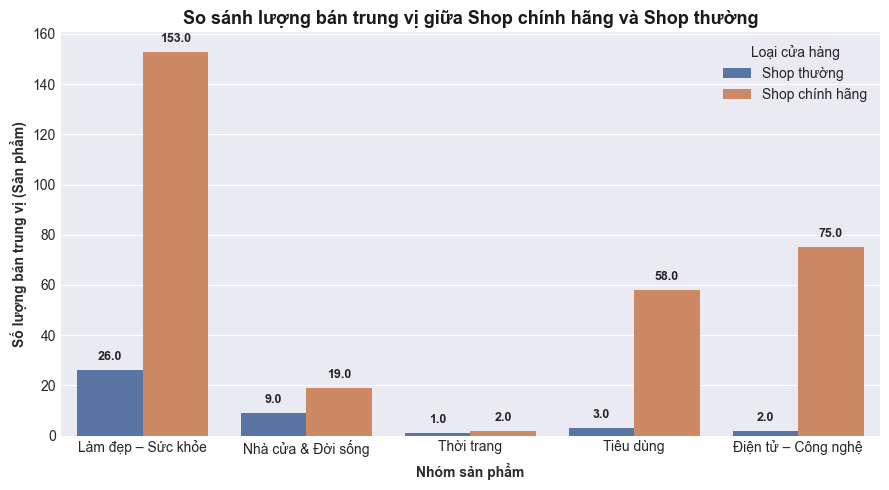

In [22]:
# Sử dụng biểu đồ cột kết hợp thang đo Logarit để quan sát sự chênh lệch rõ rệt ở cả những ngành hàng có doanh số thấp.
plt.figure(figsize=(9,5))

# Định nghĩa bảng màu: xanh cho shop thường (0), cam cho shop chính hãng (1)
palette = {
    0: "#4C72B0",  # shop thường
    1: "#DD8452"   # shop chính hãng
}

# Vẽ biểu đồ cột (Bar plot)
ax = sns.barplot(
    data=group_stats,
    x="category_group",
    y="quantity_sold_winsor",
    hue="is_official",
    palette=palette
)

# Cấu hình tiêu đề và nhãn trục
plt.title(
    "So sánh lượng bán trung vị giữa Shop chính hãng và Shop thường",
    fontsize=13, fontweight="bold", color="#1A1A1A"
)
plt.xlabel("Nhóm sản phẩm", fontweight="bold", color="#2C2C2C")
plt.ylabel("Số lượng bán trung vị (Sản phẩm)", fontweight="bold", color="#2C2C2C")

# Cấu hình chú thích (Legend)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=["Shop thường", "Shop chính hãng"],
    title="Loại cửa hàng"
)

# Hiện số cụ thể trên đầu mỗi cột
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

# Tự động căn chỉnh bố cục để không bị mất chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

### **✍️ Nhận xét:**
- Dữ liệu cho thấy sự áp đảo tuyệt đối của Shop chính hãng. Trong hầu hết các ngành hàng, Shop chính hãng có lượng bán trung vị vượt xa Shop thường. Đặc biệt tại ngành Làm đẹp - Sức khỏe, lượng bán của Shop chính hãng (153.0) gấp gần 6 lần so với Shop thường (26.0).    
  
- Niềm tin thương hiệu dẫn dắt hành vi với các ngành hàng có giá trị cao hoặc ảnh hưởng trực tiếp đến sức khỏe (Điện tử - Công nghệ, Làm đẹp - Sức khỏe, Tiêu dùng) chứng kiến sự chênh lệch lớn nhất. Điều này cho thấy khách hàng ưu tiên tuyệt đối yếu tố uy tín và nguồn gốc sản phẩm hơn là giá cả khi mua sắm các mặt hàng này.    
  
- Riêng ngành hàng Thời trang là ngoại lệ, đây là nhóm duy nhất có sự chênh lệch rất thấp (1.0 so với 2.0). Insight ở đây là: Với thời trang, người dùng quan tâm đến mẫu mã, phong cách và tính xu hướng nhiều hơn là nhãn hiệu "Chính hãng".

### **🎯Nhận định chung**:
- Vị thế "Chính hãng" là rào cản gia nhập thị trường cực lớn. Việc sở hữu mác "Chính hãng" không chỉ là một danh hiệu, mà là một lợi thế cạnh tranh mang tính sinh tồn trên sàn TMĐT. Nó tạo ra một "con hào kinh tế" giúp bảo vệ doanh số trước sự tấn công về giá của các shop nhỏ lẻ.   
     
- Tâm lý tiêu dùng dịch chuyển về sự an toàn. Biểu đồ phản ánh rõ xu hướng "mua sự an tâm". Khách hàng sẵn sàng trả mức giá chênh lệch để đổi lấy cam kết về chất lượng, đặc biệt là trong bối cảnh hàng giả, hàng nhái tràn lan.    
  
- Sự chênh lệch thấp ở ngành Thời trang cho thấy nếu biết chọn đúng ngành hàng đề cao tính cá nhân, các shop nhỏ vẫn có thể tồn tại và phát triển song song với các "ông lớn".    
    
### **🚀 Chiến lược**: 
- Việc lên "Cửa hàng chính hãng" tạo ra một rào cản lớn cho các đối thủ mới. Nếu là Shop thường, đừng cố chạy đua về giá với cửa hàng chính hãng ở các sản phẩm có thương hiệu.    
   
- Tập trung vào những sản phẩm độc lạ hoặc không có thương hiệu mạnh để giảm bớt sự ảnh hưởng từ uy tín của các cửa hàng chính hãng. 
     
- Khi không có lợi thế "Chính hãng", shop thường cần xây dựng lòng tin qua sự chăm sóc khách hàng cá nhân hóa và tốc độ phản hồi.     
  
- Đối với Tiki, nên tiếp tục đẩy mạnh các chương trình bảo chứng (như "Chính hãng 100%") để tăng doanh thu tổng thể, vì đây là "mỏ vàng" về lượng bán.    

## **5️⃣ Một số từ khóa "giật tít" trong tên sản phẩm (`product_name`) có ảnh hưởng đến điểm xếp hạng trung bình (`rating_average`) không?**  

**Lợi ích:**:
- Giúp người bán nhận ra mối nguy của việc dùng từ ngữ quá đà có thể phản tác dụng nếu trải nghiệm thực tế không tương xứng.  
  
- Nhận diện các từ khóa nhạy cảm để tập trung hoàn thiện khâu vận hành, tránh việc bị trừ điểm đánh giá do lỗi dịch vụ. 
   
- Giúp định hướng việc sử dụng các từ khóa "Lợi ích thực dụng" để tạo ra tâm lý hài lòng và điểm số Rating cao bền vững.  
  
- Giúp cửa hàng duy trì điểm số trung bình ổn định bằng cách thiết lập sự trung thực ngay từ tên sản phẩm.

**Cách thức thực hiện:** 
1. Sử dụng các hàm xử lý chuỗi để xác định sự hiện diện của các bộ từ khóa mục tiêu ("Siêu rẻ", "Hot", "Xịn") trong tiêu đề sản phẩm.
    
2. Thực hiện phân tích tác động (Impact Analysis) bằng cách tính toán hiệu số giữa Rating trung bình của nhóm "Có từ khóa" và nhóm "Không có từ khóa".   
  
3. Kết quả được thể hiện qua biểu đồ Impact Score (màu xanh cho tích cực, màu đỏ cho tiêu cực) để chỉ ra lực "kéo" điểm của từng từ khóa.


In [23]:
df_kw = pd.read_csv("../data/processed/data_before_reduction.csv")

In [24]:
# Sử dụng các hàm xử lý chuỗi để xác định sự hiện diện của các bộ từ khóa mục tiêu ("Siêu rẻ", "Hot", "Xịn") trong tiêu đề sản phẩm.

# Tạo biến tạm
keywords = [
        'chính hãng', 'cao cấp', 'freeship', 'xịn', 'hot',
        'giảm', 'sale', 'tặng', 'combo', 'bảo hành',
        'nhập khẩu', 'siêu rẻ'
    ]

for kw in keywords:
    col_name = f'kw_{kw}'
    df_kw[col_name] = (
        df_kw['product_name']
        .astype(str)
        .str.lower()
        .str.contains(kw)
        .astype(int)
)

# Tính toán sự chênh lệch cho từng từ khóa cụ thể
analysis_results = []

# Danh sách các cột chứa từ khóa cần phân tích
specific_keywords = [f'kw_{kw}' for kw in keywords]

In [25]:
# Thực hiện phân tích tác động (Impact Analysis) 
# bằng cách tính toán hiệu số giữa Rating trung bình của nhóm "Có từ khóa" và nhóm "Không có từ khóa".

for kw in specific_keywords:
    # Tách dữ liệu thành 2 nhóm: Nhóm có từ khóa (=1) và Nhóm không có từ khóa (=0)
    group_with = df_kw[df_kw[kw] == 1]['rating_average']
    group_without = df_kw[df_kw[kw] == 0]['rating_average']
    
    # Tính toán Impact Score = Trung bình Rating nhóm có - Trung bình Rating nhóm không có
    impact_score = group_with.mean() - group_without.mean()
    
    # Lưu kết quả vào danh sách
    analysis_results.append({
        'Keyword': kw.replace('kw_', '').capitalize(),
        'Impact_Score': impact_score
    })

# Chuyển đổi sang dataframe và sắp xếp
# Sắp xếp theo Impact_Score giảm dần để biểu đồ trực quan hơn
df_kw_impact = pd.DataFrame(analysis_results).sort_values(by='Impact_Score', ascending=False)

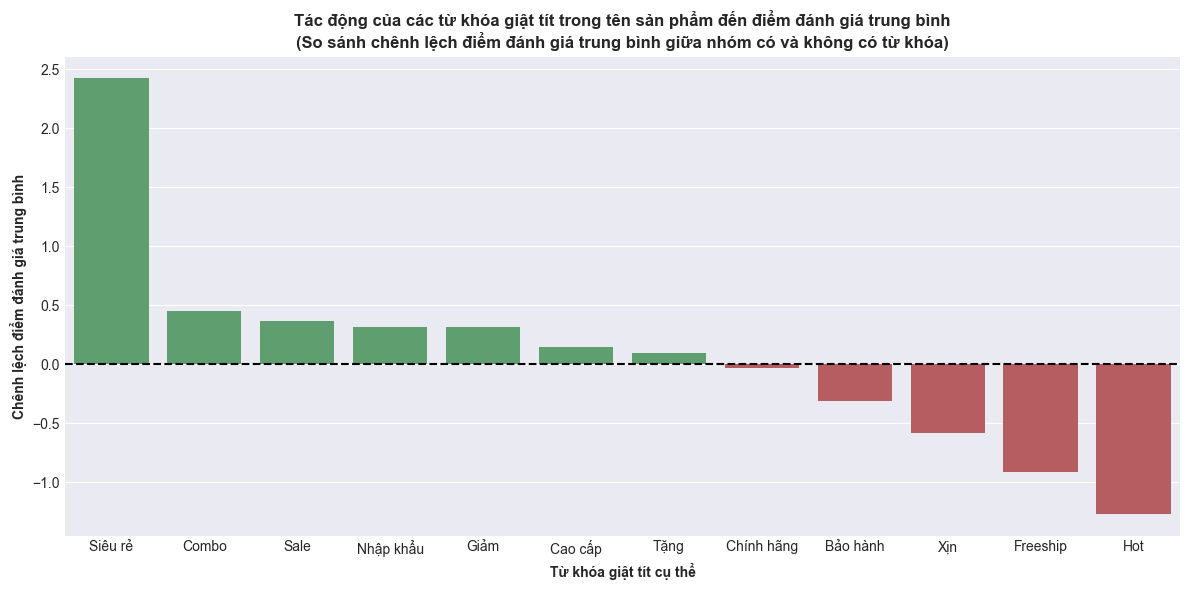

In [26]:
# Vẽ biểu đồ Impact Score (màu xanh cho tích cực, màu đỏ cho tiêu cực) để chỉ ra lực "kéo" điểm của từng từ khóa.

plt.figure(figsize=(12, 6))

# Xanh cho tác động tích cực (>0), Đỏ cho tác động tiêu cực (<0)
colors = ['#55A868' if x > 0 else '#C44E52' for x in df_kw_impact['Impact_Score']]

# Vẽ biểu đồ cột
ax = sns.barplot(data=df_kw_impact, x='Keyword', y='Impact_Score', palette=colors)

# Vẽ đường cơ sở (Baseline) tại vị trí y=0 để phân tách rõ hai nhóm tác động
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Cấu hình tiêu đề và nhãn trục
plt.title("Tác động của các từ khóa giật tít trong tên sản phẩm đến điểm đánh giá trung bình\n(So sánh chênh lệch điểm đánh giá trung bình giữa nhóm có và không có từ khóa)", fontweight='bold')
plt.xlabel("Từ khóa giật tít cụ thể", fontweight='bold')
plt.ylabel("Chênh lệch điểm đánh giá trung bình", fontweight='bold')

# Tối ưu hóa khoảng cách để không bị mất nhãn trục
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

### **✍️ Nhận xét:**
- Hiệu ứng tích cực từ nhóm từ khóa "Giá trị thực": Các từ khóa đánh vào lợi ích kinh tế rõ ràng như "Siêu rẻ", "Combo", "Sale" mang lại mức tăng trưởng điểm đánh giá trung bình cao nhất. Đặc biệt, từ khóa "Siêu rẻ" có tác động tích cực vượt trội (tăng hơn 2.0 điểm Rating), cho thấy khách hàng cảm thấy cực kỳ hài lòng khi mua được sản phẩm với giá hời so với kỳ vọng.
  
- Sự phản tác dụng của nhóm từ khóa "Hứa hẹn cảm tính": Ngược lại, các từ khóa mang tính chất tung hô hoặc hứa hẹn dịch vụ nhưng dễ gây thất vọng như "Hot", "Freeship", "Xịn", "Bảo hành" lại có chênh lệch Rating âm. Điều này chứng tỏ khi sử dụng các từ này, kỳ vọng của khách hàng bị đẩy lên rất cao; nếu sản phẩm thực tế hoặc dịch vụ vận chuyển không đáp ứng đúng "độ xịn" hay "độ hot" như quảng cáo, họ sẵn sàng đánh giá thấp.
  
- Nghịch lý "Chính hãng": Từ khóa "Chính hãng" có mức tác động gần như bằng 0 (thậm chí hơi âm nhẹ). Insight ở đây là khách hàng coi việc sản phẩm "Chính hãng" là một tiêu chuẩn mặc định, không còn là một điểm cộng để nâng điểm đánh giá, nhưng lại là yếu tố gây trừng phạt nặng nề nếu phát hiện hàng giả.

### **🎯Nhận định chung**:
- Biểu đồ phản ánh một thực tế, khách hàng ngày càng thông minh và nhạy cảm với các chiêu trò marketing. Họ có xu hướng "hào phóng" điểm số với những giá trị thực dụng (giá rẻ, combo tiện lợi) và "khắt khe" với những lời hứa hẹn hào nhoáng.  
  
- Điểm đánh giá trung bình không chỉ phụ thuộc vào chất lượng sản phẩm mà còn phụ thuộc vào khoảng cách giữa kỳ vọng (tạo ra bởi từ khóa) và trải nghiệm thực tế. Từ khóa giật tít càng mạnh nhưng thực hiện càng kém thì rủi ro bị "bão 1 sao" càng lớn.  
  
- Trong kỷ nguyên thương mại điện tử cạnh tranh, sự trung thực và các giá trị kinh tế thực tế vẫn là vũ khí sắc bén nhất để duy trì điểm số Rating cao và uy tín bền vững cho gian hàng.
    
### **🚀 Chiến lược**: 
- Nên tập trung sử dụng các từ khóa như "Siêu rẻ", "Combo", "Nhập khẩu" trong tiêu đề sản phẩm. Những từ này giúp thiết lập kỳ vọng đúng đắn và thực tế về mặt kinh tế, từ đó dễ dàng làm hài lòng khách hàng hơn.  
  
- Cẩn trọng với các từ khóa "Kỳ vọng cao" chẳng hạn như các tính từ cảm tính như "Xịn", "Hot" trừ khi sản phẩm thực sự xuất sắc. Đối với từ khóa "Freeship" và "Bảo hành", shop cần đảm bảo quy trình vận chuyển và hậu mãi phải cực kỳ chuyên nghiệp để tránh việc khách hàng trừ điểm Rating do dịch vụ không như lời chào mời.  
  
- Thay vì dùng từ "Chính hãng" một cách đơn điệu trong tên, hãy chứng minh điều đó qua hình ảnh giấy chứng nhận hoặc mô tả chi tiết để xây dựng lòng tin mà không tạo ra áp lực kỳ vọng ảo cho tiêu đề.

## **6️⃣ Mối quan hệ giữa số lượng người theo dõi (`total_follower`) của cửa hàng và số lượng bán (`quantity_sold`) của các sản phẩm là gì?**  

**Lợi ích:** 
- Giúp nhà bán hàng hiểu rõ tầm quan trọng của việc xây dựng cộng đồng người theo dõi như một kênh truyền thông hiệu quả.

- Cung cấp cơ sở để chuyển dịch một phần chi phí quảng cáo trực tiếp sang các chiến dịch tăng follow nhằm tạo doanh thu bền vững.

- Giúp shop xác định được các cột mốc follower cần thiết để đạt tới trạng thái "tự vận hành" doanh số mà không cần phụ thuộc quá nhiều vào chạy quảng cáo.

- Giúp đánh giá mức độ uy tín của cửa hàng, vì lượng follow cao thường đi kèm với tỷ lệ giữ chân khách hàng tốt hơn.

**Cách thức thực hiện:** 
1. Áp dụng thang đo Log-Log (logarit cho cả hai trục x và y) để xử lý sự chênh lệch quá lớn về quy mô giữa các shop nhỏ và shop lớn, giúp dữ liệu hiển thị tập trung và rõ ràng hơn.  
  
2. Vẽ thêm đường hồi quy (Trendline) để xác định xu hướng: nếu đường dốc lên, follower thực sự giúp tăng đơn.  
  
3. Sử dụng biểu đồ phân tán (Scatter Plot) kết hợp với đường xu hướng để quan sát mật độ tập trung của dữ liệu và các điểm đột biến.

In [27]:
# Chuẩn bị dữ liệu
# Sao chép dataframe để tránh ảnh hưởng đến dữ liệu gốc
df_plot = df.copy()

In [28]:
# Áp dụng thang đo Log-Log (logarit cho cả hai trục x và y) để xử lý sự chênh lệch quá lớn về quy mô giữa các shop nhỏ và shop lớn, giúp dữ liệu hiển thị tập trung và rõ ràng hơn.  
plt.figure(figsize=(10, 6))

# Hoàn tác phép biến đổi Log
df_plot["total_follower_winsor"] = np.expm1(df_plot["total_follower"])
df_plot["quantity_sold_winsor"] = np.expm1(df_plot["quantity_sold"])

<Figure size 1000x600 with 0 Axes>

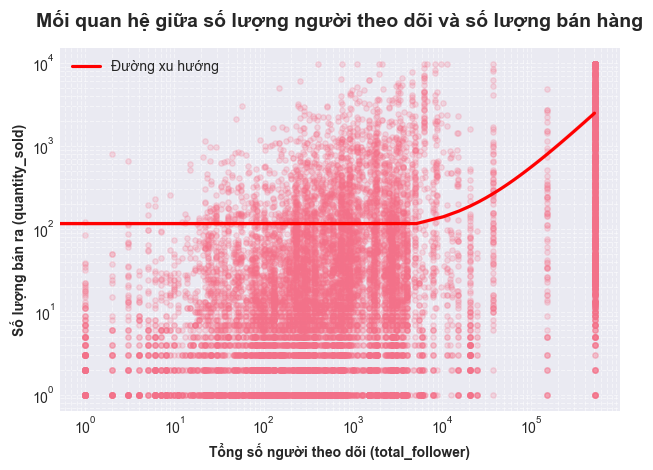

In [29]:
# Vẽ thêm đường hồi quy (Trendline) để xác định xu hướng: nếu đường dốc lên, follower thực sự giúp tăng đơn.  
# Sử dụng biểu đồ phân tán (Scatter Plot) kết hợp với đường xu hướng để quan sát mật độ tập trung của dữ liệu và các điểm đột biến.

# scatter_kws: alpha=0.2 giúp giảm độ đậm của điểm, làm nổi bật những vùng có mật độ shop tập trung cao
# line_kws: vẽ đường xu hướng màu đỏ để quan sát mối tương quan chung
sns.regplot(
    data=df_plot, 
    x="total_follower_winsor", 
    y="quantity_sold_winsor", 
    scatter_kws={'alpha':0.2, 's':15}, 
    line_kws={'color':'red', 'label':'Đường xu hướng'}
)

# Thiết lập thang đo logarit
# Vì sự chênh lệch giữa shop nhỏ và shop lớn là cực kỳ lớn, thang đo Log giúp giãn dữ liệu ở vùng giá trị thấp để quan sát rõ hơn các shop nhỏ.
plt.xscale('log')
plt.yscale('log')

# Định dạng hiển thị
plt.title("Mối quan hệ giữa số lượng người theo dõi và số lượng bán hàng", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tổng số người theo dõi (total_follower)", fontweight='bold')
plt.ylabel("Số lượng bán ra (quantity_sold)", fontweight='bold')

# Thêm lưới cho cả các vạch phụ do đang dùng thang log
plt.grid(True, which="both", ls="--", alpha=0.5)

# Hiển thị chú thích
plt.legend()

# Tự động tối ưu bố cục
plt.tight_layout()

# Xuất biểu đồ
plt.show()

### **✍️ Nhận xét:**
- Biểu đồ cho thấy một mối liên hệ tích cực rõ rệt giữa `total_follower` và `quantity_sold`. Đường xu hướng (Trendline) dốc lên khẳng định rằng khi lượng người theo dõi tăng, hiệu suất bán hàng có xu hướng cải thiện đáng kể.

- Quan sát đường xu hướng trên thang đo Log-Log, ta thấy doanh số bắt đầu tăng tốc mạnh mẽ sau khi cửa hàng vượt qua ngưỡng khoảng $10^3$ đến $10^4$ người theo dõi. Tại đây, shop bắt đầu tận dụng được hiệu ứng lan tỏa và tệp khách hàng trung thành để tạo ra đơn hàng ổn định.

- Mật độ tập trung ở phân khúc nhỏ, đa số các điểm dữ liệu tập trung ở góc dưới bên trái (lượng theo dõi thấp). Tuy nhiên, các "Outliers" ở góc trên bên phải (shop có hàng trăm nghìn follow) cho thấy sức mạnh khủng khiếp của kênh truyền thông sở hữu trong việc duy trì doanh số khủng mà không cần phụ thuộc quá nhiều vào quảng cáo trả phí.


### **🎯Nhận định chung**:
- Follower là thước đo sức mạnh thương hiệu, số lượng người theo dõi không chỉ là một con số phù phiếm mà nó còn là bằng chứng cho độ uy tín và khả năng giữ chân khách hàng của một cửa hàng.
    
- Cửa hàng có lượng theo dõi càng lớn thì chi phí vận hành marketing trên mỗi đơn hàng càng thấp. Biểu đồ chứng minh rằng việc đạt đến một ngưỡng follow nhất định sẽ giúp shop đạt được trạng thái tự vận hành doanh số một cách bền vững.

### **🚀 Chiến lược**:
- Thay vì chỉ đổ ngân sách vào quảng cáo để bán một đơn hàng duy nhất, shop nên trích một phần ngân sách để thu hút người theo dõi thông qua voucher người theo dõi mới, minigame hoặc quà tặng kèm.
    
- Lượng người theo dõi đóng vai trò là tài sản số của shop. Chiến lược lâu dài là duy trì tương tác thường xuyên với tệp này qua tính năng Live stream để giảm chi phí tiếp thị trên mỗi đơn hàng.

- Đối với các shop ở giai đoạn đầu, trọng tâm nên là tối ưu hóa chất lượng sản phẩm và đánh giá (Rating) để xây dựng niềm tin, tạo tiền đề cho việc tăng lượng người theo dõi tự nhiên.

## **7️⃣ Mức độ chi tiết của tiêu đề sản phẩm (`product_name`) có mối quan hệ gì với điểm đánh giá trung bình (`rating_average`) hay số lượng bán ra (`quantity_sold`) không?**  

**Lợi ích:**
- Giúp nhà bán hàng tìm ra độ dài tiêu đề "vàng" để cung cấp vừa đủ thông tin mà không làm khách hàng bị nhiễu.  

- Hiểu rõ ranh giới giữa việc nhồi nhét từ khóa để thuật toán nhận diện và việc viết tiêu đề mạch lạc để thu hút con người click vào xem sản phẩm và mua.  

- Giúp người bán cung cấp thông tin chuẩn xác ngay từ tiêu đề, tránh việc khách hàng mua sai sản phẩm do thông tin mập mờ, dẫn đến khiếu nại.  

- Giúp chuẩn hóa cấu trúc đặt tên sản phẩm theo hướng khoa học, giúp gian hàng trông đáng tin cậy và minh bạch hơn trong mắt người mua.  

**Cách thức thực hiện:** 
- Hình 1: 
    - Chia độ dài tiêu đề `name_word_count` thành các nhóm (<10 từ, 10-20 từ, 20-30 từ, 30-50 từ, và >50 từ).
    - Áp dụng biểu đồ Boxplot để quan sát sự phân bổ điểm đánh giá trung bình trên từng nhóm. Biểu đồ này giúp xác định dải độ dài nào mang lại điểm số cao và ổn định nhất.
- Hình 2:
    - Sử dụng biểu đồ phân tán (Scatter plot) kết hợp với thang đo Log Scale cho trục tung `quantity_sold` để quan sát rõ hơn sự thay đổi của doanh số theo từng từ.

    - Vẽ đường hồi quy bậc 2 để tìm ra điểm cực trị. Đỉnh của đường cong này sẽ chỉ ra chính xác số lượng từ lý tưởng nhất để đạt được lượng bán ra cao nhất.

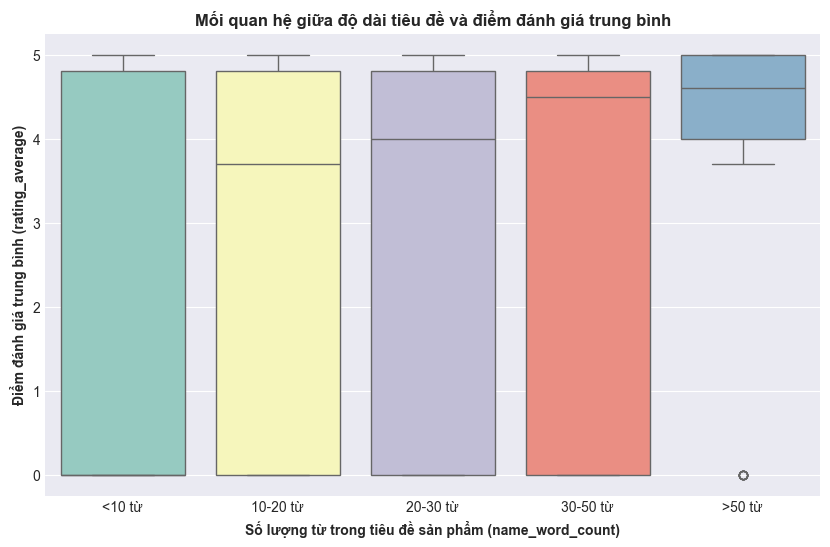

In [30]:
# Rời rạc hóa biến định lượng 'name_word_count' thành các nhóm định danh
df['word_count_bins'] = pd.cut(df['name_word_count'], bins=[0, 10, 20, 30, 50, 100], 
                              labels=['<10 từ', '10-20 từ', '20-30 từ', '30-50 từ', '>50 từ'])

plt.figure(figsize=(10, 6))

# Sử dụng Boxplot để quan sát phân phối điểm Rating
sns.boxplot(data=df, x='word_count_bins', y='rating_average', palette='Set3')

# Định dạng hiển thị
plt.title("Mối quan hệ giữa độ dài tiêu đề và điểm đánh giá trung bình", fontweight='bold')
plt.xlabel("Số lượng từ trong tiêu đề sản phẩm (name_word_count)", fontweight='bold')
plt.ylabel("Điểm đánh giá trung bình (rating_average)", fontweight='bold')

# Xuất biểu đồ
plt.show()

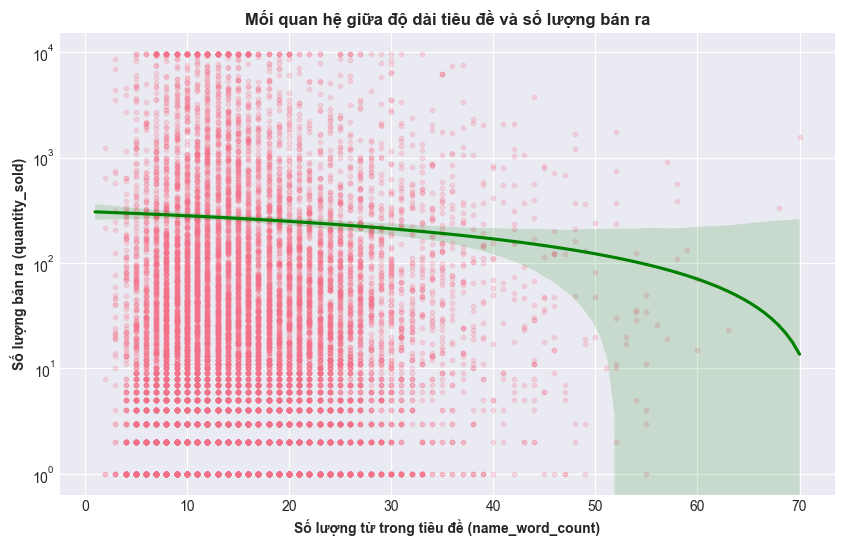

In [31]:
plt.figure(figsize=(10, 6))

# Sử dụng regplot với order=2 để khớp mô hình hồi quy Bậc 2 (đường cong Parabol)
# - scatter_kws: alpha=0.2 để xử lý hiện tượng chồng lấp dữ liệu
# - order=2: Giúp xác định đỉnh parabol mà tại đó doanh số đạt mức cao nhất
sns.regplot(data=df, x="name_word_count", y="quantity_sold_winsor", 
            order=2, scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'green'})

# Chuyển trục Y sang thang đo Logarit
plt.yscale('log') 

# Định dạng hiển thị
plt.title("Mối quan hệ giữa độ dài tiêu đề và số lượng bán ra", fontweight='bold')
plt.xlabel("Số lượng từ trong tiêu đề (name_word_count)", fontweight='bold')
plt.ylabel("Số lượng bán ra (quantity_sold)", fontweight='bold')

# Xuất biểu đồ
plt.show()

### **✍️ Nhận xét:**
- Qua biểu đồ Boxplot, nhóm sản phẩm có tiêu đề từ 20-30 từ và thậm chí trên 50 từ có dải điểm đánh giá trung bình tập trung cao và ổn định hơn. Tuy nhiên, biểu đồ phân tán Scatter plot với đường hồi quy bậc 2 cho thấy số lượng bán ra (quantity sold) đạt đỉnh khi tiêu đề nằm trong khoảng từ 15 đến 25 từ.  

- Tiêu đề quá ngắn (dưới 10 từ) thường gây cảm giác thiếu thông tin, khiến khách hàng nghi ngờ về độ tin cậy của shop. Ngược lại, tiêu đề quá dài (trên 40 từ) gây hiện tượng "nhiễu thông tin", khiến người mua bị choáng ngợp và khó nắm bắt đặc điểm chính của sản phẩm.  

- Đường cong Parabol trên biểu đồ doanh số có xu hướng đi xuống rõ rệt sau ngưỡng 40 từ, chứng minh rằng việc nhồi nhét từ khóa không giúp tăng tỷ lệ chuyển đổi mà còn có tác dụng ngược.  

### **🎯Nhận định chung**:
- Tiêu đề cần đủ dài để thuật toán tìm kiếm nhận diện (SEO), nhưng phải đủ gọn gàng để con người có thể tiếp nhận hiệu quả (UX).  

- Chất lượng thông tin quyết định hành vi mua sắm, qua biểu đồ khẳng định rằng sự chi tiết vừa phải trong tiêu đề có mối tương quan thuận với niềm tin của khách hàng (thể hiện qua điểm đánh giá (rating) trung bình ổn định).  

- Một tiêu đề được tối ưu tốt không chỉ giúp bán được nhiều hàng hơn mà còn giúp giảm tỷ lệ khiếu nại/đổi trả, vì khách hàng đã hiểu đúng bản chất sản phẩm ngay từ bước tìm kiếm.

### **🚀 Chiến lược**:
- Khuyến nghị các nhà bán hàng đặt tiêu đề sản phẩm trong khoảng 20 từ. Đây là độ dài vừa đủ để chứa các thành phần cốt lõi: [Tên sản phẩm] + [Thương hiệu] + [Đặc tính nổi bật] + [Thông số kỹ thuật].  

- Cấu trúc tiêu đề nên ưu tiên thông tin quan trọng vì khách hàng thường chỉ đọc lướt 5-7 từ đầu tiên, hãy đưa những từ khóa giá trị nhất lên đầu tiêu đề để lọc đúng khách hàng mục tiêu ngay lập tức.  

- Kiểm soát chất lượng nội dung thay vì số lượng, thay vì cố gắng viết dài để tối ưu SEO, hãy tập trung vào sự rõ ràng và chính xác. Tiêu đề cần giúp khách hàng xác nhận "đây đúng là thứ tôi cần" trong vòng 2 giây.